<a href="https://colab.research.google.com/github/faisu6339-glitch/Real_World-Projects/blob/main/Customer_Recommendation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [349]:
import numpy as np
import pandas as pd

In [350]:
df=pd.read_csv('Amazon.csv', engine='python', on_bad_lines='warn')

In [351]:
df.head()

,id,name,asins,brand,categories,keys,manufacturer,reviews.date,reviews.dateAdded,reviews.dateSeen,...,reviews.doRecommend,reviews.id,reviews.numHelpful,reviews.rating,reviews.sourceURLs,reviews.text,reviews.title,reviews.userCity,reviews.userProvince,reviews.username
0,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-13T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,True,NaN,0.0,5.0,http://reviews.bestbuy.com/3545/5620406/review...,This product so far has not disappointed. My c...,Kindle,NaN,NaN,Adapter
1,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-13T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,True,NaN,0.0,5.0,http://reviews.bestbuy.com/3545/5620406/review...,great for beginner or experienced person. Boug...,very fast,NaN,NaN,truman
2,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-13T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,True,NaN,0.0,5.0,http://reviews.bestbuy.com/3545/5620406/review...,Inexpensive tablet for him to use and learn on...,Beginner tablet for our 9 year old son.,NaN,NaN,DaveZ
3,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-13T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,True,NaN,0.0,4.0,http://reviews.bestbuy.com/3545/5620406/review...,I've had my Fire HD 8 two weeks now and I love...,Good!!!,NaN,NaN,Shacks
4,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-12T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,True,NaN,0.0,5.0,http://reviews.bestbuy.com/3545/5620406/review...,I bought this for my grand daughter when she c...,Fantastic Tablet for kids,NaN,NaN,explore42


In [352]:
df.columns

Index(['id', 'name', 'asins', 'brand', 'categories', 'keys', 'manufacturer',
       'reviews.date', 'reviews.dateAdded', 'reviews.dateSeen',
       'reviews.didPurchase', 'reviews.doRecommend', 'reviews.id',
       'reviews.numHelpful', 'reviews.rating', 'reviews.sourceURLs',
       'reviews.text', 'reviews.title', 'reviews.userCity',
       'reviews.userProvince', 'reviews.username'],
      dtype='object')

In [353]:
df.describe()

,reviews.id,reviews.numHelpful,reviews.rating,reviews.userCity,reviews.userProvince
count,1.0,34131.000000,34627.000000,0.0,0.0
mean,111372787.0,0.630248,4.584573,NaN,NaN
std,NaN,13.215775,0.735653,NaN,NaN
min,111372787.0,0.000000,1.000000,NaN,NaN
25%,111372787.0,0.000000,4.000000,NaN,NaN
50%,111372787.0,0.000000,5.000000,NaN,NaN
75%,111372787.0,0.000000,5.000000,NaN,NaN
max,111372787.0,814.000000,5.000000,NaN,NaN


In [354]:
df.shape

(34660, 21)

In [355]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34660 entries, 0 to 34659
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    34660 non-null  object 
 1   name                  27900 non-null  object 
 2   asins                 34658 non-null  object 
 3   brand                 34660 non-null  object 
 4   categories            34660 non-null  object 
 5   keys                  34660 non-null  object 
 6   manufacturer          34660 non-null  object 
 7   reviews.date          34621 non-null  object 
 8   reviews.dateAdded     24039 non-null  object 
 9   reviews.dateSeen      34660 non-null  object 
 10  reviews.didPurchase   1 non-null      object 
 11  reviews.doRecommend   34066 non-null  object 
 12  reviews.id            1 non-null      float64
 13  reviews.numHelpful    34131 non-null  float64
 14  reviews.rating        34627 non-null  float64
 15  reviews.sourceURLs 

In [356]:
df.isna()

,id,name,asins,brand,categories,keys,manufacturer,reviews.date,reviews.dateAdded,reviews.dateSeen,...,reviews.doRecommend,reviews.id,reviews.numHelpful,reviews.rating,reviews.sourceURLs,reviews.text,reviews.title,reviews.userCity,reviews.userProvince,reviews.username
0,False,False,False,False,False,False,False,False,False,False,...,False,True,False,False,False,False,False,True,True,False
1,False,False,False,False,False,False,False,False,False,False,...,False,True,False,False,False,False,False,True,True,False
2,False,False,False,False,False,False,False,False,False,False,...,False,True,False,False,False,False,False,True,True,False
3,False,False,False,False,False,False,False,False,False,False,...,False,True,False,False,False,False,False,True,True,False
4,False,False,False,False,False,False,False,False,False,False,...,False,True,False,False,False,False,False,True,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34655,False,True,False,False,False,False,False,False,True,False,...,True,True,True,False,False,False,False,True,True,False
34656,False,True,False,False,False,False,False,False,True,False,...,True,True,True,False,False,False,False,True,True,False
34657,False,True,False,False,False,False,False,False,True,False,...,True,True,True,False,False,False,False,True,True,False
34658,False,True,False,False,False,False,False,False,True,False,...,True,True,True,False,False,False,False,True,True,False


#Step -1 Handling Missing values

In [357]:
df.isnull().sum()

,0
id,0
name,6760
asins,2
brand,0
categories,0
keys,0
manufacturer,0
reviews.date,39
reviews.dateAdded,10621
reviews.dateSeen,0


In [358]:
(df.isnull().mean() * 100).sort_values(ascending=False)

,0
reviews.userCity,100.000000
reviews.userProvince,100.000000
reviews.id,99.997115
reviews.didPurchase,99.997115
reviews.dateAdded,30.643393
name,19.503751
reviews.doRecommend,1.713791
reviews.numHelpful,1.526255
reviews.date,0.112522
reviews.rating,0.095211


#Separating Num_cols And Cat_cols

In [359]:
num_cols=df.select_dtypes(include=np.number).columns
cat_cols=df.select_dtypes(include='object').columns

In [360]:
num_cols

Index(['reviews.id', 'reviews.numHelpful', 'reviews.rating',
       'reviews.userCity', 'reviews.userProvince'],
      dtype='object')

In [361]:
cat_cols

Index(['id', 'name', 'asins', 'brand', 'categories', 'keys', 'manufacturer',
       'reviews.date', 'reviews.dateAdded', 'reviews.dateSeen',
       'reviews.didPurchase', 'reviews.doRecommend', 'reviews.sourceURLs',
       'reviews.text', 'reviews.title', 'reviews.username'],
      dtype='object')

In [362]:
print(f"Total Numerical Columns: {len(num_cols)}")
print(f"Total Categorical Columns: {len(cat_cols)}")

Total Numerical Columns: 5
Total Categorical Columns: 16


In [363]:
df = df.drop(columns=['reviews.userCity', 'reviews.userProvince', 'reviews.id'])

In [364]:
df=df.drop(columns=['reviews.didPurchase'])

In [365]:
num_cols

Index(['reviews.id', 'reviews.numHelpful', 'reviews.rating',
       'reviews.userCity', 'reviews.userProvince'],
      dtype='object')

In [366]:
print(f"Total Numerical Columns: {len(num_cols)}")
print(f"Total Categorical Columns: {len(cat_cols)}")

Total Numerical Columns: 5
Total Categorical Columns: 16


In [367]:
print(df.columns)

Index(['id', 'name', 'asins', 'brand', 'categories', 'keys', 'manufacturer',
       'reviews.date', 'reviews.dateAdded', 'reviews.dateSeen',
       'reviews.doRecommend', 'reviews.numHelpful', 'reviews.rating',
       'reviews.sourceURLs', 'reviews.text', 'reviews.title',
       'reviews.username'],
      dtype='object')


#Analyzing the columns

In [368]:
df['reviews.dateAdded']

,reviews.dateAdded
0,2017-07-03T23:33:15Z
1,2017-07-03T23:33:15Z
2,2017-07-03T23:33:15Z
3,2017-07-03T23:33:15Z
4,2017-07-03T23:33:15Z
...,...
34655,NaN
34656,NaN
34657,NaN
34658,NaN


In [369]:
df['reviews.dateAdded'].value_counts()

,count
reviews.dateAdded,
2017-09-05T22:09:30Z,3127
2017-09-20T05:35:53Z,1831
2017-09-20T05:35:52Z,800
2017-09-20T05:35:59Z,799
2017-09-20T05:35:54Z,560
...,...
2017-05-21T06:01:34Z,1
2017-05-21T06:00:46Z,1
2017-05-21T06:00:42Z,1


#Convert to datetime

In [370]:
df['reviews.dateAdded'] = pd.to_datetime(df['reviews.dateAdded'], errors='coerce')

In [371]:
df['year'] = df['reviews.dateAdded'].dt.year
df['month'] = df['reviews.dateAdded'].dt.month
df['day'] = df['reviews.dateAdded'].dt.day
df['day_of_week'] = df['reviews.dateAdded'].dt.day_name()

In [372]:
df.head()

,id,name,asins,brand,categories,keys,manufacturer,reviews.date,reviews.dateAdded,reviews.dateSeen,...,reviews.numHelpful,reviews.rating,reviews.sourceURLs,reviews.text,reviews.title,reviews.username,year,month,day,day_of_week
0,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-13T00:00:00.000Z,2017-07-03 23:33:15+00:00,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,0.0,5.0,http://reviews.bestbuy.com/3545/5620406/review...,This product so far has not disappointed. My c...,Kindle,Adapter,2017.0,7.0,3.0,Monday
1,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-13T00:00:00.000Z,2017-07-03 23:33:15+00:00,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,0.0,5.0,http://reviews.bestbuy.com/3545/5620406/review...,great for beginner or experienced person. Boug...,very fast,truman,2017.0,7.0,3.0,Monday
2,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-13T00:00:00.000Z,2017-07-03 23:33:15+00:00,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,0.0,5.0,http://reviews.bestbuy.com/3545/5620406/review...,Inexpensive tablet for him to use and learn on...,Beginner tablet for our 9 year old son.,DaveZ,2017.0,7.0,3.0,Monday
3,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-13T00:00:00.000Z,2017-07-03 23:33:15+00:00,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,0.0,4.0,http://reviews.bestbuy.com/3545/5620406/review...,I've had my Fire HD 8 two weeks now and I love...,Good!!!,Shacks,2017.0,7.0,3.0,Monday
4,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-12T00:00:00.000Z,2017-07-03 23:33:15+00:00,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,0.0,5.0,http://reviews.bestbuy.com/3545/5620406/review...,I bought this for my grand daughter when she c...,Fantastic Tablet for kids,explore42,2017.0,7.0,3.0,Monday


#Pipeline

In [373]:
num_cols = df.select_dtypes(include='number').columns
cat_cols = df.select_dtypes(exclude='number').columns

Create imputation pipelines

In [374]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Numerical pipeline
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median'))
])

# Categorical pipeline
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent'))
])

Combine using ColumnTransformer

In [375]:
from sklearn.compose import ColumnTransformer
preprocessor=ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
])

In [376]:
#df_transformed = preprocessor.fit_transform(df)

In [377]:
#df = pd.DataFrame(preprocessor.fit_transform(df),
              #    columns=preprocessor.get_feature_names_out())

In [378]:
#print(type(df_transformed))

In [379]:
#print(df_transformed[:5])

In [380]:
#print(df_transformed.shape)

#Using SimpleImputer WITHOUT Pipeline

In [381]:
from sklearn.impute import SimpleImputer

# Numerical
#num_imputer = SimpleImputer(strategy='median')
#df[num_cols] = num_imputer.fit_transform(df[num_cols])

# Categorical
#cat_imputer = SimpleImputer(strategy='most_frequent')
#df[cat_cols] = cat_imputer.fit_transform(df[cat_cols])

“Initially, I handled missing values using pandas fillna for exploration. Later, I implemented sklearn’s Pipeline with SimpleImputer to ensure consistency and avoid data leakage.”

In [382]:
(df.isnull().mean() * 100).sort_values(ascending=False)

,0
year,30.643393
day_of_week,30.643393
day,30.643393
month,30.643393
reviews.dateAdded,30.643393
name,19.503751
reviews.doRecommend,1.713791
reviews.numHelpful,1.526255
reviews.date,0.112522
reviews.rating,0.095211


In [383]:
df.columns[df.isnull().any()]

Index(['name', 'asins', 'reviews.date', 'reviews.dateAdded',
       'reviews.doRecommend', 'reviews.numHelpful', 'reviews.rating',
       'reviews.text', 'reviews.title', 'reviews.username', 'year', 'month',
       'day', 'day_of_week'],
      dtype='object')

In [384]:
df.head()

,id,name,asins,brand,categories,keys,manufacturer,reviews.date,reviews.dateAdded,reviews.dateSeen,...,reviews.numHelpful,reviews.rating,reviews.sourceURLs,reviews.text,reviews.title,reviews.username,year,month,day,day_of_week
0,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-13T00:00:00.000Z,2017-07-03 23:33:15+00:00,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,0.0,5.0,http://reviews.bestbuy.com/3545/5620406/review...,This product so far has not disappointed. My c...,Kindle,Adapter,2017.0,7.0,3.0,Monday
1,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-13T00:00:00.000Z,2017-07-03 23:33:15+00:00,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,0.0,5.0,http://reviews.bestbuy.com/3545/5620406/review...,great for beginner or experienced person. Boug...,very fast,truman,2017.0,7.0,3.0,Monday
2,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-13T00:00:00.000Z,2017-07-03 23:33:15+00:00,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,0.0,5.0,http://reviews.bestbuy.com/3545/5620406/review...,Inexpensive tablet for him to use and learn on...,Beginner tablet for our 9 year old son.,DaveZ,2017.0,7.0,3.0,Monday
3,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-13T00:00:00.000Z,2017-07-03 23:33:15+00:00,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,0.0,4.0,http://reviews.bestbuy.com/3545/5620406/review...,I've had my Fire HD 8 two weeks now and I love...,Good!!!,Shacks,2017.0,7.0,3.0,Monday
4,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-12T00:00:00.000Z,2017-07-03 23:33:15+00:00,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,0.0,5.0,http://reviews.bestbuy.com/3545/5620406/review...,I bought this for my grand daughter when she c...,Fantastic Tablet for kids,explore42,2017.0,7.0,3.0,Monday


#Step -2 Handling the Num_cols & Cat_cols

#Encoding

Num_cols

In [385]:
print(num_cols)

Index(['reviews.numHelpful', 'reviews.rating', 'year', 'month', 'day'], dtype='object')


In [386]:
print([col for col in num_cols if col not in df.columns])

[]


In [387]:
num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(include='object').columns

In [388]:
num_cols

Index(['reviews.numHelpful', 'reviews.rating', 'year', 'month', 'day'], dtype='object')

In [389]:
df.loc[:, num_cols].head(10)

,reviews.numHelpful,reviews.rating,year,month,day
0,0.0,5.0,2017.0,7.0,3.0
1,0.0,5.0,2017.0,7.0,3.0
2,0.0,5.0,2017.0,7.0,3.0
3,0.0,4.0,2017.0,7.0,3.0
4,0.0,5.0,2017.0,7.0,3.0
5,0.0,5.0,2017.0,7.0,3.0
6,0.0,4.0,2017.0,7.0,3.0
7,0.0,5.0,2017.0,7.0,3.0
8,0.0,5.0,2017.0,7.0,3.0
9,0.0,5.0,2017.0,7.0,3.0


In [390]:
from IPython.display import display
display(df.loc[:, num_cols])

,reviews.numHelpful,reviews.rating,year,month,day
0,0.0,5.0,2017.0,7.0,3.0
1,0.0,5.0,2017.0,7.0,3.0
2,0.0,5.0,2017.0,7.0,3.0
3,0.0,4.0,2017.0,7.0,3.0
4,0.0,5.0,2017.0,7.0,3.0
...,...,...,...,...,...
34655,NaN,3.0,NaN,NaN,NaN
34656,NaN,1.0,NaN,NaN,NaN
34657,NaN,1.0,NaN,NaN,NaN
34658,NaN,1.0,NaN,NaN,NaN


In [391]:
df[list(num_cols)]

,reviews.numHelpful,reviews.rating,year,month,day
0,0.0,5.0,2017.0,7.0,3.0
1,0.0,5.0,2017.0,7.0,3.0
2,0.0,5.0,2017.0,7.0,3.0
3,0.0,4.0,2017.0,7.0,3.0
4,0.0,5.0,2017.0,7.0,3.0
...,...,...,...,...,...
34655,NaN,3.0,NaN,NaN,NaN
34656,NaN,1.0,NaN,NaN,NaN
34657,NaN,1.0,NaN,NaN,NaN
34658,NaN,1.0,NaN,NaN,NaN


In [392]:
df[num_cols].head()

,reviews.numHelpful,reviews.rating,year,month,day
0,0.0,5.0,2017.0,7.0,3.0
1,0.0,5.0,2017.0,7.0,3.0
2,0.0,5.0,2017.0,7.0,3.0
3,0.0,4.0,2017.0,7.0,3.0
4,0.0,5.0,2017.0,7.0,3.0


In [393]:
df.head()

,id,name,asins,brand,categories,keys,manufacturer,reviews.date,reviews.dateAdded,reviews.dateSeen,...,reviews.numHelpful,reviews.rating,reviews.sourceURLs,reviews.text,reviews.title,reviews.username,year,month,day,day_of_week
0,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-13T00:00:00.000Z,2017-07-03 23:33:15+00:00,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,0.0,5.0,http://reviews.bestbuy.com/3545/5620406/review...,This product so far has not disappointed. My c...,Kindle,Adapter,2017.0,7.0,3.0,Monday
1,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-13T00:00:00.000Z,2017-07-03 23:33:15+00:00,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,0.0,5.0,http://reviews.bestbuy.com/3545/5620406/review...,great for beginner or experienced person. Boug...,very fast,truman,2017.0,7.0,3.0,Monday
2,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-13T00:00:00.000Z,2017-07-03 23:33:15+00:00,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,0.0,5.0,http://reviews.bestbuy.com/3545/5620406/review...,Inexpensive tablet for him to use and learn on...,Beginner tablet for our 9 year old son.,DaveZ,2017.0,7.0,3.0,Monday
3,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-13T00:00:00.000Z,2017-07-03 23:33:15+00:00,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,0.0,4.0,http://reviews.bestbuy.com/3545/5620406/review...,I've had my Fire HD 8 two weeks now and I love...,Good!!!,Shacks,2017.0,7.0,3.0,Monday
4,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-12T00:00:00.000Z,2017-07-03 23:33:15+00:00,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,0.0,5.0,http://reviews.bestbuy.com/3545/5620406/review...,I bought this for my grand daughter when she c...,Fantastic Tablet for kids,explore42,2017.0,7.0,3.0,Monday


In [394]:
print(cat_cols)

Index(['id', 'name', 'asins', 'brand', 'categories', 'keys', 'manufacturer',
       'reviews.date', 'reviews.dateSeen', 'reviews.doRecommend',
       'reviews.sourceURLs', 'reviews.text', 'reviews.title',
       'reviews.username', 'day_of_week'],
      dtype='object')


In [396]:
print(cat_cols)

Index(['id', 'name', 'asins', 'brand', 'categories', 'keys', 'manufacturer',
       'reviews.date', 'reviews.dateSeen', 'reviews.doRecommend',
       'reviews.sourceURLs', 'reviews.text', 'reviews.title',
       'reviews.username', 'day_of_week'],
      dtype='object')


In [397]:
cols_to_drop = [
    'cat__id',
    'cat__asins',
    'cat__keys',
    'cat__reviews.username',
    'cat__reviews.sourceURLs',
    'cat__reviews.text',
    'cat__reviews.title'
]

In [398]:
df = df.drop(columns=cols_to_drop, errors='ignore')

In [399]:
print(df.columns)

Index(['id', 'name', 'asins', 'brand', 'categories', 'keys', 'manufacturer',
       'reviews.date', 'reviews.dateAdded', 'reviews.dateSeen',
       'reviews.doRecommend', 'reviews.numHelpful', 'reviews.rating',
       'reviews.sourceURLs', 'reviews.text', 'reviews.title',
       'reviews.username', 'year', 'month', 'day', 'day_of_week'],
      dtype='object')


In [400]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34660 entries, 0 to 34659
Data columns (total 21 columns):
 #   Column               Non-Null Count  Dtype              
---  ------               --------------  -----              
 0   id                   34660 non-null  object             
 1   name                 27900 non-null  object             
 2   asins                34658 non-null  object             
 3   brand                34660 non-null  object             
 4   categories           34660 non-null  object             
 5   keys                 34660 non-null  object             
 6   manufacturer         34660 non-null  object             
 7   reviews.date         34621 non-null  object             
 8   reviews.dateAdded    24039 non-null  datetime64[ns, UTC]
 9   reviews.dateSeen     34660 non-null  object             
 10  reviews.doRecommend  34066 non-null  object             
 11  reviews.numHelpful   34131 non-null  float64            
 12  reviews.rating    

#Fix Numerical Columns

In [401]:
df[num_cols].dtypes

,0
reviews.numHelpful,float64
reviews.rating,float64
year,float64
month,float64
day,float64


#Drop useless columns

#Handle remaining categorical columns

In [403]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34660 entries, 0 to 34659
Data columns (total 21 columns):
 #   Column               Non-Null Count  Dtype              
---  ------               --------------  -----              
 0   id                   34660 non-null  object             
 1   name                 27900 non-null  object             
 2   asins                34658 non-null  object             
 3   brand                34660 non-null  object             
 4   categories           34660 non-null  object             
 5   keys                 34660 non-null  object             
 6   manufacturer         34660 non-null  object             
 7   reviews.date         34621 non-null  object             
 8   reviews.dateAdded    24039 non-null  datetime64[ns, UTC]
 9   reviews.dateSeen     34660 non-null  object             
 10  reviews.doRecommend  34066 non-null  object             
 11  reviews.numHelpful   34131 non-null  float64            
 12  reviews.rating    

In [404]:
df.head()

,id,name,asins,brand,categories,keys,manufacturer,reviews.date,reviews.dateAdded,reviews.dateSeen,...,reviews.numHelpful,reviews.rating,reviews.sourceURLs,reviews.text,reviews.title,reviews.username,year,month,day,day_of_week
0,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-13T00:00:00.000Z,2017-07-03 23:33:15+00:00,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,0.0,5.0,http://reviews.bestbuy.com/3545/5620406/review...,This product so far has not disappointed. My c...,Kindle,Adapter,2017.0,7.0,3.0,Monday
1,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-13T00:00:00.000Z,2017-07-03 23:33:15+00:00,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,0.0,5.0,http://reviews.bestbuy.com/3545/5620406/review...,great for beginner or experienced person. Boug...,very fast,truman,2017.0,7.0,3.0,Monday
2,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-13T00:00:00.000Z,2017-07-03 23:33:15+00:00,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,0.0,5.0,http://reviews.bestbuy.com/3545/5620406/review...,Inexpensive tablet for him to use and learn on...,Beginner tablet for our 9 year old son.,DaveZ,2017.0,7.0,3.0,Monday
3,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-13T00:00:00.000Z,2017-07-03 23:33:15+00:00,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,0.0,4.0,http://reviews.bestbuy.com/3545/5620406/review...,I've had my Fire HD 8 two weeks now and I love...,Good!!!,Shacks,2017.0,7.0,3.0,Monday
4,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-12T00:00:00.000Z,2017-07-03 23:33:15+00:00,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,0.0,5.0,http://reviews.bestbuy.com/3545/5620406/review...,I bought this for my grand daughter when she c...,Fantastic Tablet for kids,explore42,2017.0,7.0,3.0,Monday


In [405]:
df['brand'].value_counts().head(10)

,count
brand,
Amazon,28701
Amazon Fire Tv,5056
Amazon Echo,636
Amazon Fire,256
Amazon Digital Services Inc.,10
Amazon Coco T,1


In [406]:
df.columns

Index(['id', 'name', 'asins', 'brand', 'categories', 'keys', 'manufacturer',
       'reviews.date', 'reviews.dateAdded', 'reviews.dateSeen',
       'reviews.doRecommend', 'reviews.numHelpful', 'reviews.rating',
       'reviews.sourceURLs', 'reviews.text', 'reviews.title',
       'reviews.username', 'year', 'month', 'day', 'day_of_week'],
      dtype='object')

#Univariate Analysis

In [407]:
print(cat_cols)

Index(['id', 'name', 'asins', 'brand', 'categories', 'keys', 'manufacturer',
       'reviews.date', 'reviews.dateSeen', 'reviews.doRecommend',
       'reviews.sourceURLs', 'reviews.text', 'reviews.title',
       'reviews.username', 'day_of_week'],
      dtype='object')


In [408]:
print(num_cols)

Index(['reviews.numHelpful', 'reviews.rating', 'year', 'month', 'day'], dtype='object')


In [409]:
df['name'].value_counts().head(10)

,count
name,
"Fire Tablet, 7 Display, Wi-Fi, 8 GB - Includes Special Offers, Magenta",10966
"Echo (White),,,\r\nEcho (White),,,",3309
"Amazon Kindle Paperwhite - eBook reader - 4 GB - 6 monochrome Paperwhite - touchscreen - Wi-Fi - black,,,",3176
"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi, 16 GB - Includes Special Offers, Magenta",2814
"Amazon Fire Tv,,,\r\nAmazon Fire Tv,,,",2527
"Fire Kids Edition Tablet, 7 Display, Wi-Fi, 16 GB, Green Kid-Proof Case",1685
"Brand New Amazon Kindle Fire 16gb 7 Ips Display Tablet Wifi 16 Gb Blue,,,",1038
"Kindle Voyage E-reader, 6 High-Resolution Display (300 ppi) with Adaptive Built-in Light, PagePress Sensors, Wi-Fi - Includes Special Offers,",580
"Fire Tablet, 7 Display, Wi-Fi, 8 GB - Includes Special Offers, Black",372


#CLEANING the Messy data

1. Name

In [410]:
df['name'] = df['name'].str.replace(r'\r\n', ' ', regex=True)
df['name'] = df['name'].str.replace(r'\n', ' ', regex=True)
df['name'] = df['name'].str.replace(r'\s+', ' ', regex=True)
df['name'] = df['name'].str.strip()

In [411]:
df['name'].value_counts().head(10)

,count
name,
"Fire Tablet, 7 Display, Wi-Fi, 8 GB - Includes Special Offers, Magenta",10966
"Echo (White),,, Echo (White),,,",3309
"Amazon Kindle Paperwhite - eBook reader - 4 GB - 6 monochrome Paperwhite - touchscreen - Wi-Fi - black,,,",3176
"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi, 16 GB - Includes Special Offers, Magenta",2814
"Amazon Fire Tv,,, Amazon Fire Tv,,,",2527
"Fire Kids Edition Tablet, 7 Display, Wi-Fi, 16 GB, Green Kid-Proof Case",1685
"Brand New Amazon Kindle Fire 16gb 7 Ips Display Tablet Wifi 16 Gb Blue,,,",1038
"Kindle Voyage E-reader, 6 High-Resolution Display (300 ppi) with Adaptive Built-in Light, PagePress Sensors, Wi-Fi - Includes Special Offers,",580
"Fire Tablet, 7 Display, Wi-Fi, 8 GB - Includes Special Offers, Black",372


In [412]:
num_cols

Index(['reviews.numHelpful', 'reviews.rating', 'year', 'month', 'day'], dtype='object')

In [413]:
df[num_cols].describe()

,reviews.numHelpful,reviews.rating,year,month,day
count,34131.000000,34627.000000,24039.000000,24039.000000,24039.000000
mean,0.630248,4.584573,2016.999917,6.501518,17.359000
std,13.215775,0.735653,0.009121,1.904052,6.793771
min,0.000000,1.000000,2016.000000,3.000000,2.000000
25%,0.000000,4.000000,2017.000000,5.000000,20.000000
50%,0.000000,5.000000,2017.000000,5.000000,21.000000
75%,0.000000,5.000000,2017.000000,9.000000,21.000000
max,814.000000,5.000000,2017.000000,12.000000,29.000000


In [414]:
df[num_cols] = df[num_cols].fillna(0)

In [415]:
df['helpfulness_ratio'] = df['reviews.numHelpful'] / (df['reviews.rating'] + 1)

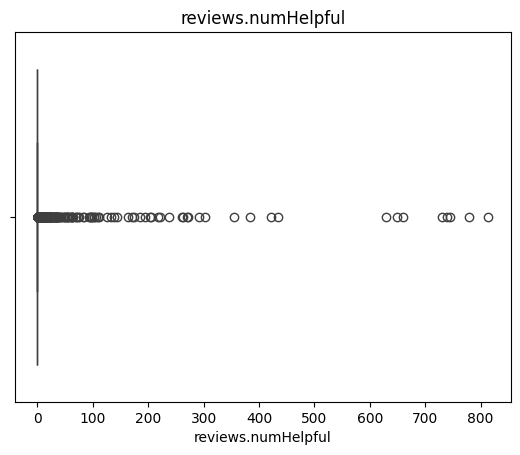

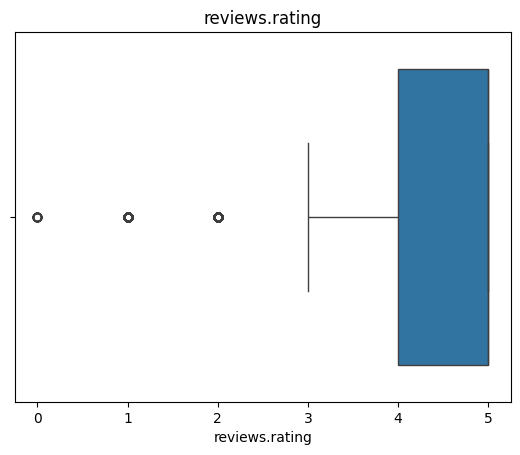

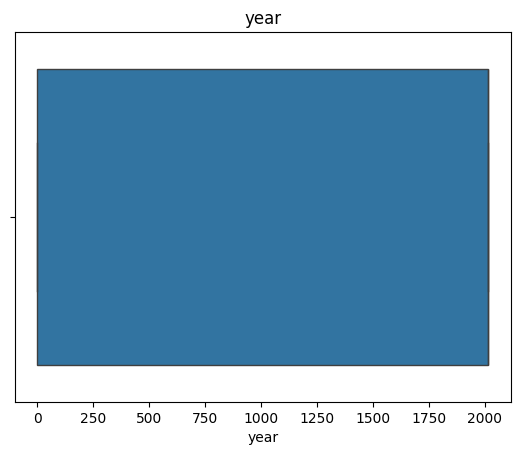

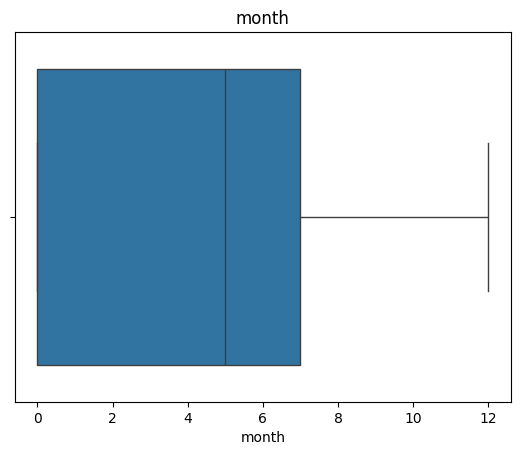

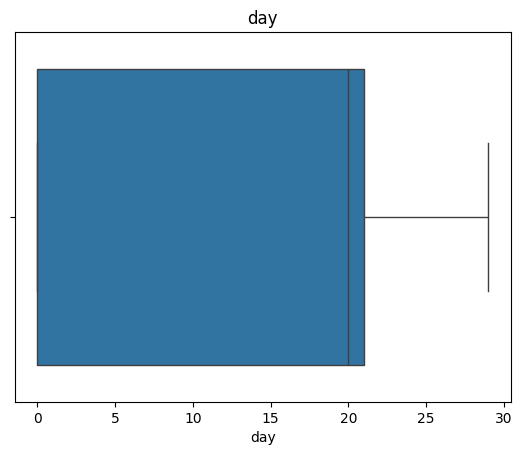

In [416]:
import seaborn as sns
import matplotlib.pyplot as plt

for col in num_cols:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

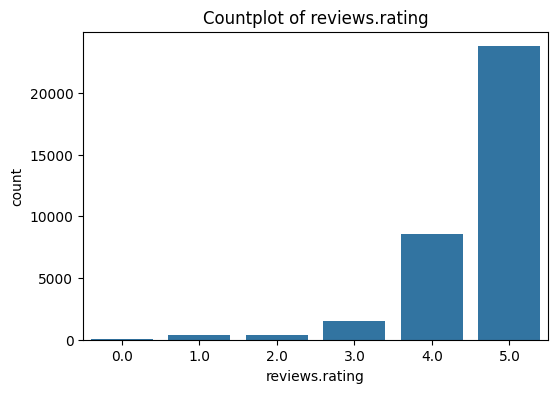

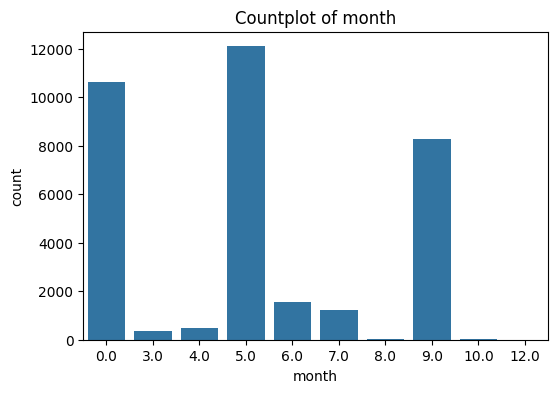

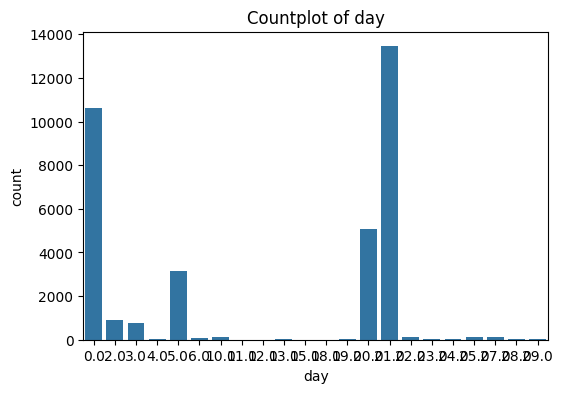

In [417]:
for col in ['reviews.rating', 'month', 'day']:
    plt.figure(figsize=(6,4))
    sns.countplot(x=df[col])
    plt.title(f'Countplot of {col}')
    plt.show()


🔹 Analysis of reviews.numHelpful
count    34660.000000
mean         0.620629
std         13.114759
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        814.000000
Name: reviews.numHelpful, dtype: float64


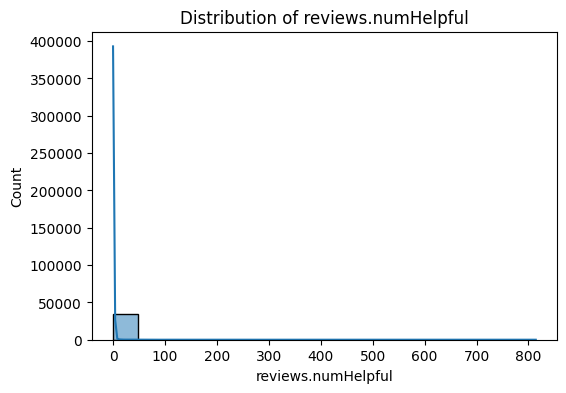

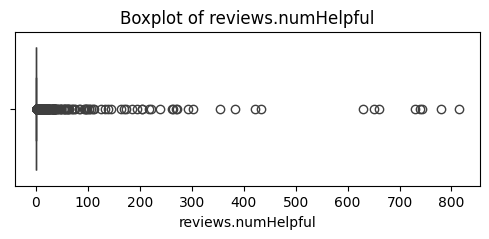


🔹 Analysis of reviews.rating
count    34660.000000
mean         4.580208
std          0.748774
min          0.000000
25%          4.000000
50%          5.000000
75%          5.000000
max          5.000000
Name: reviews.rating, dtype: float64


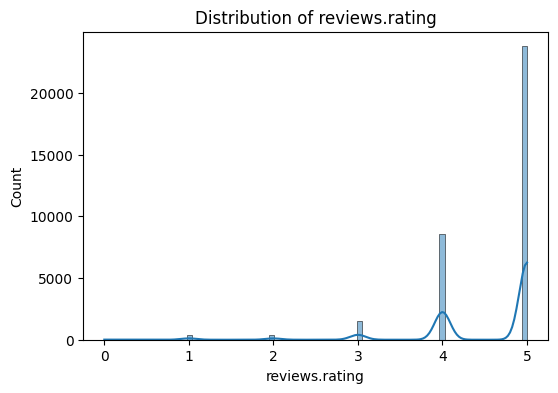

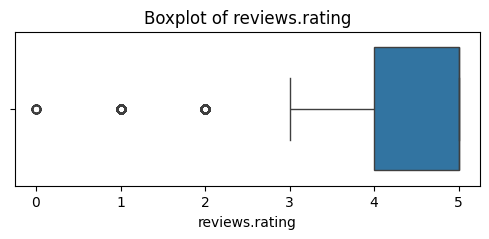


🔹 Analysis of year
count    34660.000000
mean      1398.922706
std        929.874826
min          0.000000
25%          0.000000
50%       2017.000000
75%       2017.000000
max       2017.000000
Name: year, dtype: float64


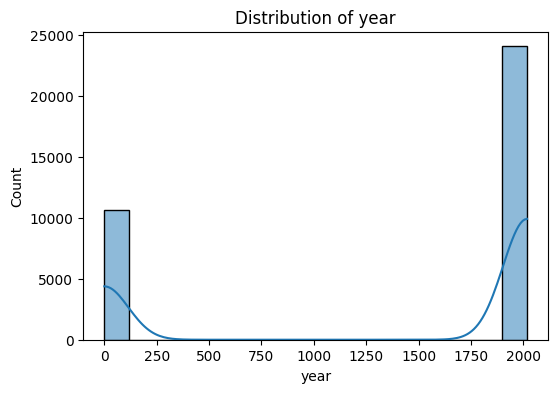

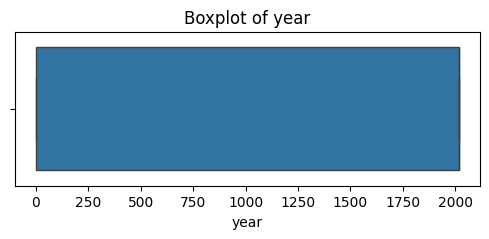


🔹 Analysis of month
count    34660.000000
mean         4.509233
std          3.390925
min          0.000000
25%          0.000000
50%          5.000000
75%          7.000000
max         12.000000
Name: month, dtype: float64


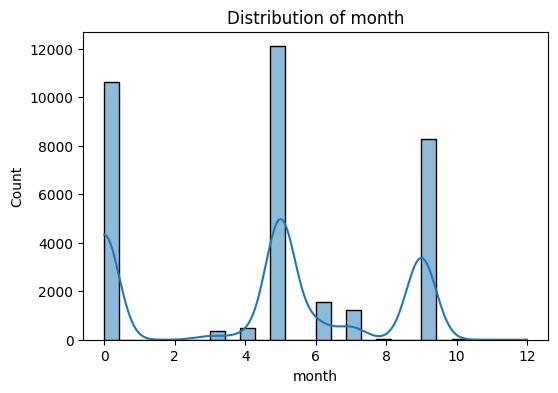

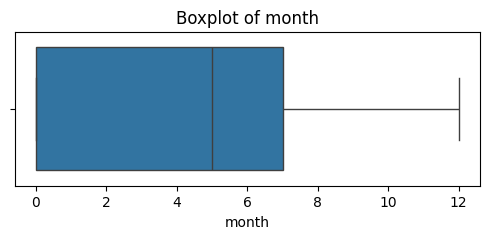


🔹 Analysis of day
count    34660.000000
mean        12.039613
std          9.800845
min          0.000000
25%          0.000000
50%         20.000000
75%         21.000000
max         29.000000
Name: day, dtype: float64


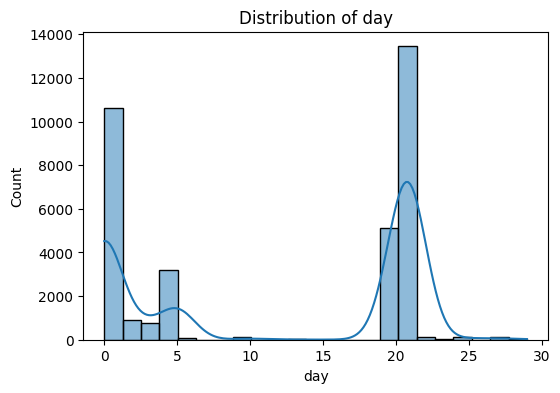

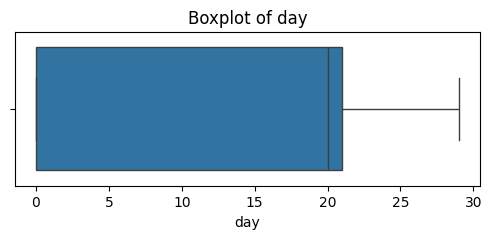

In [418]:
import matplotlib.pyplot as plt
import seaborn as sns

for col in num_cols:
    print(f"\n🔹 Analysis of {col}")

    # Summary stats
    print(df[col].describe())

    # Histogram
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

    # Boxplot
    plt.figure(figsize=(6,2))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

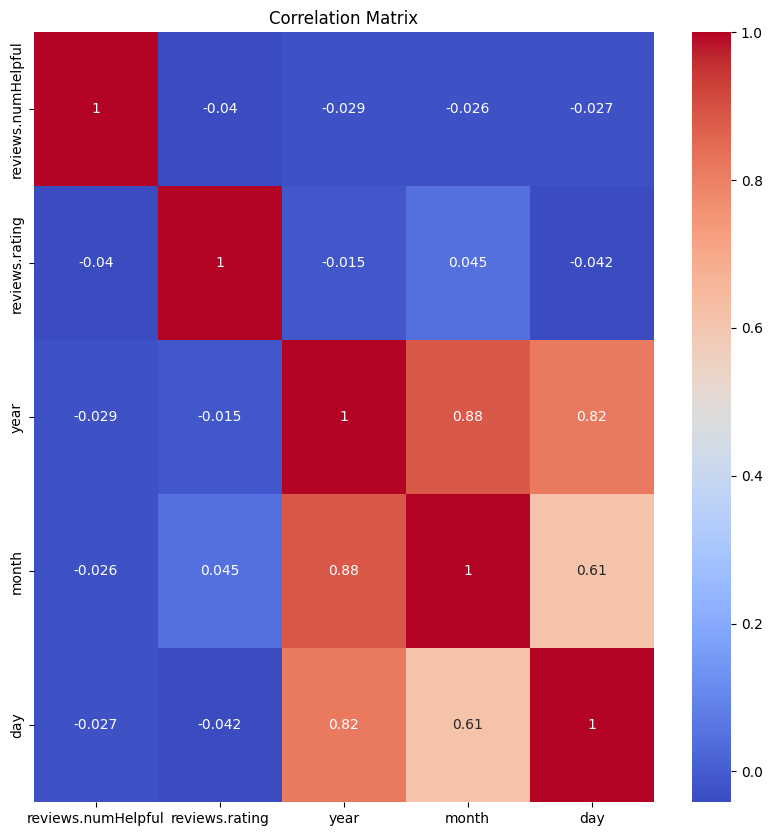

In [419]:
corr=df[num_cols].corr()
plt.figure(figsize=(10,10))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

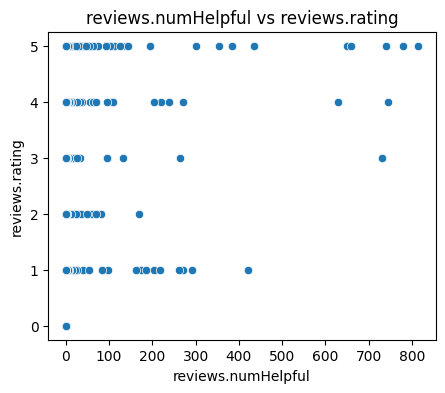

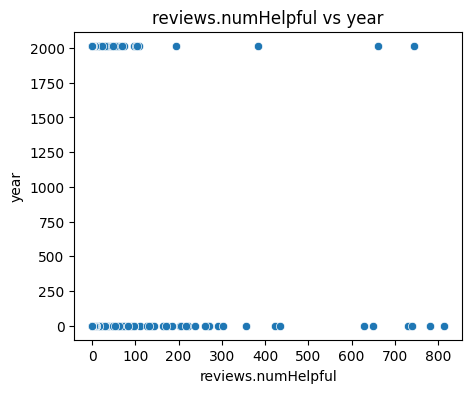

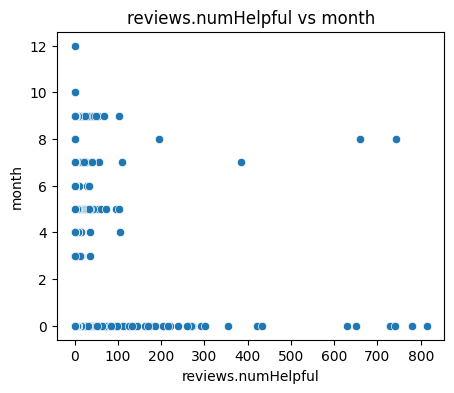

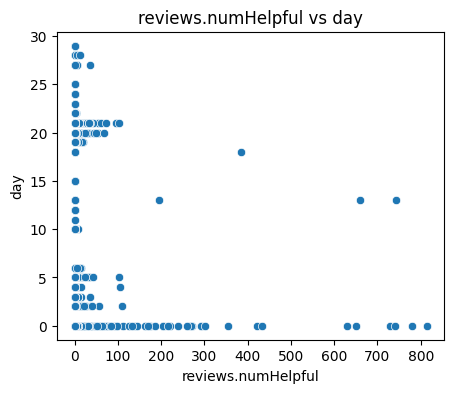

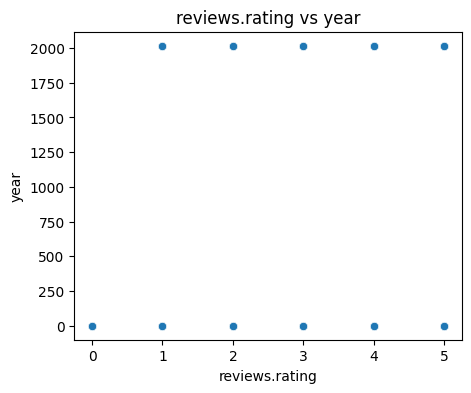

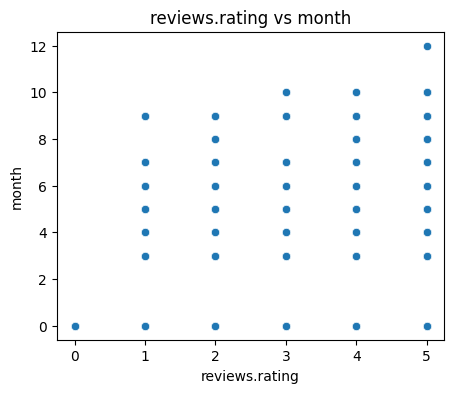

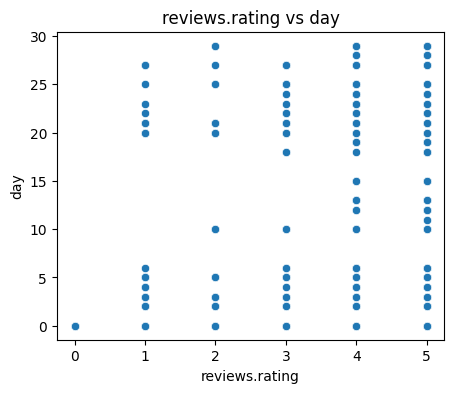

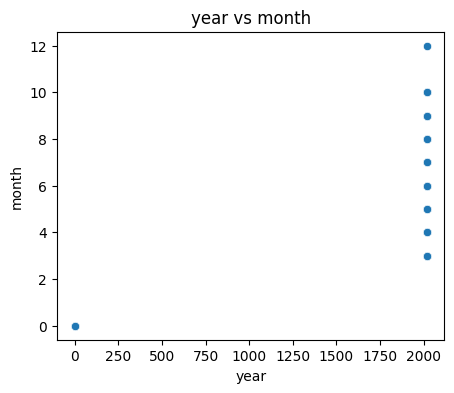

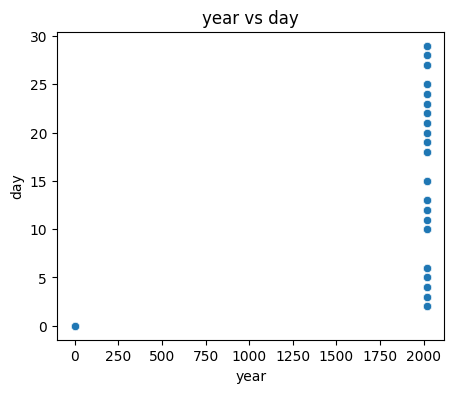

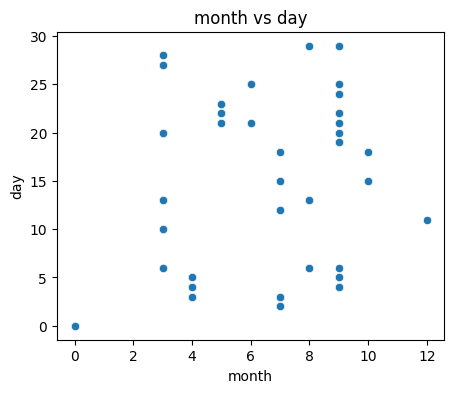

In [420]:
for i in range(len(num_cols)):
    for j in range(i+1, len(num_cols)):
        plt.figure(figsize=(5,4))
        sns.scatterplot(x=df[num_cols[i]], y=df[num_cols[j]])
        plt.title(f"{num_cols[i]} vs {num_cols[j]}")
        plt.show()

In [421]:
cat_cols

Index(['id', 'name', 'asins', 'brand', 'categories', 'keys', 'manufacturer',
       'reviews.date', 'reviews.dateSeen', 'reviews.doRecommend',
       'reviews.sourceURLs', 'reviews.text', 'reviews.title',
       'reviews.username', 'day_of_week'],
      dtype='object')

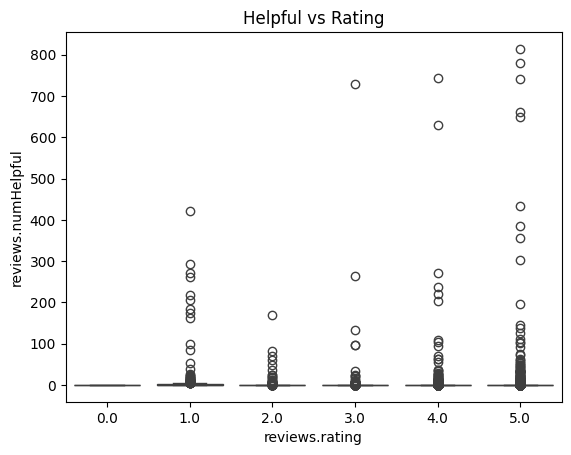

In [422]:
sns.boxplot(x=df['reviews.rating'], y=df['reviews.numHelpful'])
plt.title("Helpful vs Rating")
plt.show()

In [423]:
df.groupby('reviews.rating')['reviews.numHelpful'].mean()

,reviews.numHelpful
reviews.rating,
0.0,0.000000
1.0,7.426829
2.0,1.883085
3.0,1.156104
4.0,0.570542
5.0,0.467003


In [424]:
df['reviews.rating'].value_counts()

,count
reviews.rating,
5.0,23775
4.0,8541
3.0,1499
1.0,410
2.0,402
0.0,33


In [425]:
df['asins'].unique()

array(['B01AHB9CN2', 'B00VINDBJK', 'B005PB2T0S', 'B002Y27P3M',
       'B01AHB9CYG', 'B01AHB9C1E', 'B01J2G4VBG', 'B00ZV9PXP2',
       'B0083Q04TA', 'B018Y229OU', 'B00REQKWGA', 'B00IOYAM4I',
       'B018T075DC', nan, 'B00DU15MU4', 'B018Y225IA', 'B005PB2T2Q',
       'B018Y23MNM', 'B00OQVZDJM', 'B00IOY8XWQ', 'B00LO29KXQ',
       'B00QJDU3KY', 'B018Y22C2Y', 'B01BFIBRIE', 'B01J4ORNHU',
       'B018SZT3BK', 'B00UH4D8G2', 'B018Y22BI4', 'B00TSUGXKE',
       'B00L9EPT8O,B01E6AO69U', 'B018Y23P7K', 'B00X4WHP5E', 'B00QFQRELG',
       'B00LW9XOJM', 'B00QL1ZN3G', 'B0189XYY0Q', 'B01BH83OOM',
       'B00BFJAHF8', 'B00U3FPN4U', 'B002Y27P6Y', 'B006GWO5NE',
       'B006GWO5WK'], dtype=object)

In [426]:
df['asins'].value_counts()

,count
asins,
B018Y229OU,10966
"B00L9EPT8O,B01E6AO69U",6619
B00U3FPN4U,5056
B00OQVZDJM,3176
B01AHB9CN2,2814
B018Y23MNM,1685
B018Y225IA,1038
B01BH83OOM,636
B00IOY8XWQ,580


In [427]:
df['manufacturer'].unique()

array(['Amazon', 'Amazon Digital Services, Inc'], dtype=object)

In [428]:
df['categories'].unique()

array(['Electronics,iPad & Tablets,All Tablets,Fire Tablets,Tablets,Computers & Tablets',
       'eBook Readers,Kindle E-readers,Computers & Tablets,E-Readers & Accessories,E-Readers',
       'Electronics,eBook Readers & Accessories,Covers,Kindle Store,Amazon Device Accessories,Kindle E-Reader Accessories,Kindle (5th Generation) Accessories,Kindle (5th Generation) Covers',
       'Kindle Store,Amazon Devices,Electronics',
       'Tablets,Fire Tablets,Electronics,Computers,Computer Components,Hard Drives & Storage,Computers & Tablets,All Tablets',
       'Tablets,Fire Tablets,Computers & Tablets,All Tablets',
       'Amazon Devices & Accessories,Amazon Device Accessories,Power Adapters & Cables,Kindle Store,Kindle E-Reader Accessories,Kindle Paperwhite Accessories',
       'Electronics,iPad & Tablets,All Tablets,Computers/Tablets & Networking,Tablets & eBook Readers,Computers & Tablets,E-Readers & Accessories,E-Readers,Used:Computers Accessories,Used:Tablets,Computers,iPads Tablets,Kind

In [429]:
df['categories'].value_counts()

,count
categories,
"Fire Tablets,Tablets,Computers & Tablets,All Tablets,Electronics, Tech Toys, Movies, Music,Electronics,iPad & Tablets,Android Tablets,Frys",10966
"Stereos,Remote Controls,Amazon Echo,Audio Docks & Mini Speakers,Amazon Echo Accessories,Kitchen & Dining Features,Speaker Systems,Electronics,TVs Entertainment,Clearance,Smart Hubs & Wireless Routers,Featured Brands,Wireless Speakers,Smart Home & Connected Living,Home Security,Kindle Store,Home Automation,Home, Garage & Office,Home,Voice-Enabled Smart Assistants,Virtual Assistant Speakers,Portable Audio & Headphones,Electronics Features,Amazon Device Accessories,iPod, Audio Player Accessories,Home & Furniture Clearance,Consumer Electronics,Smart Home,Surveillance,Home Improvement,Smart Home & Home Automation Devices,Smart Hubs,Home Safety & Security,Voice Assistants,Alarms & Sensors,Amazon Devices,Audio,Holiday Shop",6619
"Back To College,College Electronics,College Tvs & Home Theater,Electronics,Tvs & Home Theater,Streaming Devices,Featured Brands,Amazon Devices,Holiday Shop,Ways To Shop,TV & Home Theater,Streaming Media Players,All Streaming Media Players,TVs Entertainment,Video Games,Kindle Store,Electronics Features,Kids & Family,Fire TV",5056
"Walmart for Business,Office Electronics,Tablets,Office,Electronics,iPad & Tablets,Windows Tablets,All Windows Tablets,Computers & Tablets,E-Readers & Accessories,E-Readers,eBook Readers,Kindle E-readers,Computers/Tablets & Networking,Tablets & eBook Readers,Electronics Features,Books & Magazines,Book Accessories,eReaders,TVs & Electronics,Computers & Laptops,Tablets & eReaders",3176
"Electronics,iPad & Tablets,All Tablets,Fire Tablets,Tablets,Computers & Tablets",2814
"Tablets,Fire Tablets,Computers & Tablets,All Tablets",1699
"Computers/Tablets & Networking,Tablets & eBook Readers,Computers & Tablets,Tablets,All Tablets",1038
"Featured Brands,Electronics,Amazon Devices,Home,Home Improvement,Home Safety & Security,Home Security,Alarms & Sensors,Smart Home & Home Automation Devices,Mobile,Mobile Speakers,Mobile Bluetooth Speakers,Smart Hubs & Wireless Routers,Smart Hubs,Home, Garage & Office,Smart Home,Voice Assistants,Smart Home & Connected Living,Amazon Tap,Portable Audio,MP3 Accessories,Speakers,Amazon Echo,Electronics Features,TVs & Electronics,Portable Audio & Electronics,MP3 Player Accessories,Home Theater & Audio,Kindle Store,Frys,Electronic Components,Home Automation,Electronics, Tech Toys, Movies, Music,Audio,Bluetooth Speakers",636
"Walmart for Business,Office Electronics,Tablets,Electronics,iPad & Tablets,All Tablets,Computers & Tablets,E-Readers & Accessories,Kindle E-readers,Electronics Features,eBook Readers,See more Amazon Kindle Voyage (Wi-Fi),See more Amazon Kindle Voyage 4GB, Wi-Fi 3G (Unlocked...",580


In [430]:
df['categories_list'] = df['categories'].str.split(',')

In [431]:
df['main_category'] = df['categories_list'].apply(lambda x: x[0])

In [432]:
df['sub_category'] = df['categories_list'].apply(lambda x: x[1] if len(x) > 1 else 'unknown')

In [433]:
df['is_tablet'] = df['categories'].str.contains('tablet').astype(int)
df['is_kindle'] = df['categories'].str.contains('kindle').astype(int)
df['is_electronics'] = df['categories'].str.contains('electronics').astype(int)
df['is_smart_device'] = df['categories'].str.contains('smart').astype(int)

In [434]:
df['num_categories'] = df['categories_list'].apply(len)

In [435]:
from collections import Counter

all_cats = df['categories_list'].sum()
top_cats = [cat for cat, _ in Counter(all_cats).most_common(10)]

In [436]:
all_cats

['Electronics',
 'iPad & Tablets',
 'All Tablets',
 'Fire Tablets',
 'Tablets',
 'Computers & Tablets',
 'Electronics',
 'iPad & Tablets',
 'All Tablets',
 'Fire Tablets',
 'Tablets',
 'Computers & Tablets',
 'Electronics',
 'iPad & Tablets',
 'All Tablets',
 'Fire Tablets',
 'Tablets',
 'Computers & Tablets',
 'Electronics',
 'iPad & Tablets',
 'All Tablets',
 'Fire Tablets',
 'Tablets',
 'Computers & Tablets',
 'Electronics',
 'iPad & Tablets',
 'All Tablets',
 'Fire Tablets',
 'Tablets',
 'Computers & Tablets',
 'Electronics',
 'iPad & Tablets',
 'All Tablets',
 'Fire Tablets',
 'Tablets',
 'Computers & Tablets',
 'Electronics',
 'iPad & Tablets',
 'All Tablets',
 'Fire Tablets',
 'Tablets',
 'Computers & Tablets',
 'Electronics',
 'iPad & Tablets',
 'All Tablets',
 'Fire Tablets',
 'Tablets',
 'Computers & Tablets',
 'Electronics',
 'iPad & Tablets',
 'All Tablets',
 'Fire Tablets',
 'Tablets',
 'Computers & Tablets',
 'Electronics',
 'iPad & Tablets',
 'All Tablets',
 'Fire Tablet

In [437]:
df.head(5)

,id,name,asins,brand,categories,keys,manufacturer,reviews.date,reviews.dateAdded,reviews.dateSeen,...,day_of_week,helpfulness_ratio,categories_list,main_category,sub_category,is_tablet,is_kindle,is_electronics,is_smart_device,num_categories
0,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-13T00:00:00.000Z,2017-07-03 23:33:15+00:00,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,Monday,0.0,"[Electronics, iPad & Tablets, All Tablets, Fir...",Electronics,iPad & Tablets,0,0,0,0,6
1,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-13T00:00:00.000Z,2017-07-03 23:33:15+00:00,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,Monday,0.0,"[Electronics, iPad & Tablets, All Tablets, Fir...",Electronics,iPad & Tablets,0,0,0,0,6
2,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-13T00:00:00.000Z,2017-07-03 23:33:15+00:00,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,Monday,0.0,"[Electronics, iPad & Tablets, All Tablets, Fir...",Electronics,iPad & Tablets,0,0,0,0,6
3,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-13T00:00:00.000Z,2017-07-03 23:33:15+00:00,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,Monday,0.0,"[Electronics, iPad & Tablets, All Tablets, Fir...",Electronics,iPad & Tablets,0,0,0,0,6
4,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-12T00:00:00.000Z,2017-07-03 23:33:15+00:00,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,Monday,0.0,"[Electronics, iPad & Tablets, All Tablets, Fir...",Electronics,iPad & Tablets,0,0,0,0,6


In [438]:
df['categories_list'].value_counts()

,count
categories_list,
"[Fire Tablets, Tablets, Computers & Tablets, All Tablets, Electronics, Tech Toys, Movies, Music, Electronics, iPad & Tablets, Android Tablets, Frys]",10966
"[Stereos, Remote Controls, Amazon Echo, Audio Docks & Mini Speakers, Amazon Echo Accessories, Kitchen & Dining Features, Speaker Systems, Electronics, TVs Entertainment, Clearance, Smart Hubs & Wireless Routers, Featured Brands, Wireless Speakers, Smart Home & Connected Living, Home Security, Kindle Store, Home Automation, Home, Garage & Office, Home, Voice-Enabled Smart Assistants, Virtual Assistant Speakers, Portable Audio & Headphones, Electronics Features, Amazon Device Accessories, iPod, Audio Player Accessories, Home & Furniture Clearance, Consumer Electronics, Smart Home, Surveillance, Home Improvement, Smart Home & Home Automation Devices, Smart Hubs, Home Safety & Security, Voice Assistants, Alarms & Sensors, Amazon Devices, Audio, Holiday Shop]",6619
"[Back To College, College Electronics, College Tvs & Home Theater, Electronics, Tvs & Home Theater, Streaming Devices, Featured Brands, Amazon Devices, Holiday Shop, Ways To Shop, TV & Home Theater, Streaming Media Players, All Streaming Media Players, TVs Entertainment, Video Games, Kindle Store, Electronics Features, Kids & Family, Fire TV]",5056
"[Walmart for Business, Office Electronics, Tablets, Office, Electronics, iPad & Tablets, Windows Tablets, All Windows Tablets, Computers & Tablets, E-Readers & Accessories, E-Readers, eBook Readers, Kindle E-readers, Computers/Tablets & Networking, Tablets & eBook Readers, Electronics Features, Books & Magazines, Book Accessories, eReaders, TVs & Electronics, Computers & Laptops, Tablets & eReaders]",3176
"[Electronics, iPad & Tablets, All Tablets, Fire Tablets, Tablets, Computers & Tablets]",2814
"[Tablets, Fire Tablets, Computers & Tablets, All Tablets]",1699
"[Computers/Tablets & Networking, Tablets & eBook Readers, Computers & Tablets, Tablets, All Tablets]",1038
"[Featured Brands, Electronics, Amazon Devices, Home, Home Improvement, Home Safety & Security, Home Security, Alarms & Sensors, Smart Home & Home Automation Devices, Mobile, Mobile Speakers, Mobile Bluetooth Speakers, Smart Hubs & Wireless Routers, Smart Hubs, Home, Garage & Office, Smart Home, Voice Assistants, Smart Home & Connected Living, Amazon Tap, Portable Audio, MP3 Accessories, Speakers, Amazon Echo, Electronics Features, TVs & Electronics, Portable Audio & Electronics, MP3 Player Accessories, Home Theater & Audio, Kindle Store, Frys, Electronic Components, Home Automation, Electronics, Tech Toys, Movies, Music, Audio, Bluetooth Speakers]",636
"[Walmart for Business, Office Electronics, Tablets, Electronics, iPad & Tablets, All Tablets, Computers & Tablets, E-Readers & Accessories, Kindle E-readers, Electronics Features, eBook Readers, See more Amazon Kindle Voyage (Wi-Fi), See more Amazon Kindle Voyage 4GB, Wi-Fi 3G (Unlocked...]",580


In [439]:
df.columns

Index(['id', 'name', 'asins', 'brand', 'categories', 'keys', 'manufacturer',
       'reviews.date', 'reviews.dateAdded', 'reviews.dateSeen',
       'reviews.doRecommend', 'reviews.numHelpful', 'reviews.rating',
       'reviews.sourceURLs', 'reviews.text', 'reviews.title',
       'reviews.username', 'year', 'month', 'day', 'day_of_week',
       'helpfulness_ratio', 'categories_list', 'main_category', 'sub_category',
       'is_tablet', 'is_kindle', 'is_electronics', 'is_smart_device',
       'num_categories'],
      dtype='object')

#Main Category

In [440]:
df['main_category']

,main_category
0,Electronics
1,Electronics
2,Electronics
3,Electronics
4,Electronics
...,...
34655,Computers/Tablets & Networking
34656,Computers/Tablets & Networking
34657,Computers/Tablets & Networking
34658,Computers/Tablets & Networking


In [441]:
df['main_category'].unique()

array(['Electronics', 'eBook Readers', 'Kindle Store', 'Tablets',
       'Amazon Devices & Accessories', 'Computers/Tablets & Networking',
       'Fire Tablets', 'Kindle E-readers', 'Computers & Tablets', 'Frys',
       'Amazon Device Accessories', 'Walmart for Business', 'mazon.co.uk',
       'Categories', 'Electronics Features', 'Stereos',
       'TVs Entertainment', 'Chargers & Adapters', 'Cases',
       'Featured Brands', 'Rice Dishes', 'Back To College',
       'Power Adapters & Cables'], dtype=object)

In [442]:
df['main_category'].value_counts()

,count
main_category,
Fire Tablets,11244
Stereos,6619
Back To College,5056
Walmart for Business,3756
Electronics,3357
Tablets,1857
Computers/Tablets & Networking,1055
Featured Brands,636
Amazon Devices & Accessories,402


#Sub Category

In [443]:
df['sub_category']

,sub_category
0,iPad & Tablets
1,iPad & Tablets
2,iPad & Tablets
3,iPad & Tablets
4,iPad & Tablets
...,...
34655,Tablet & eBook Reader Accs
34656,Tablet & eBook Reader Accs
34657,Tablet & eBook Reader Accs
34658,Tablet & eBook Reader Accs


In [444]:
df['sub_category'].unique()

array(['iPad & Tablets', 'Kindle E-readers',
       'eBook Readers & Accessories', 'Amazon Devices', 'Fire Tablets',
       'Amazon Device Accessories', 'Tablets & eBook Readers', 'Tablets',
       'Electronics Features', 'E-Readers & Accessories',
       'Software & Books', 'Categories', 'Kindle Store',
       'Office Electronics', 'Computers', 'Streaming Media Players',
       'Remote Controls', 'Wireless Speakers', 'Computers & Accessories',
       'Tablets & E-Readers', 'Electronics', 'Ready Meals',
       'College Electronics', 'Tablet & eBook Reader Accs'], dtype=object)

In [445]:
df['sub_category'].value_counts()

,count
sub_category,
Tablets,11254
Remote Controls,6619
College Electronics,5056
Office Electronics,3756
iPad & Tablets,3056
Fire Tablets,2229
Tablets & eBook Readers,1042
Electronics,644
Amazon Device Accessories,412


In [446]:
df['categories_list'] = df['categories'].str.split(',')
df['main_category'] = df['categories_list'].apply(lambda x: x[0])
df['sub_category'] = df['categories_list'].apply(lambda x: x[1] if len(x)>1 else 'unknown')

#Adding Price Columns

In [484]:
import numpy as np

np.random.seed(42)

df['price'] = np.random.randint(5000, 20000, size=len(df))

In [485]:
import numpy as np

# Cost price
df['cost_price'] = df['price'] * np.random.uniform(0.6, 0.9, size=len(df))

# Selling price (can be lower OR higher)
df['selling_price'] = df['cost_price'] * np.random.uniform(0.7, 1.3, size=len(df))

In [486]:
df.drop('price', axis=1, inplace=True)

In [487]:
df['profit'] = df['selling_price'] - df['cost_price']

In [488]:
df['profit_status'] = df['profit'].apply(lambda x: 'Profit' if x > 0 else 'Loss')

In [449]:
cat_good = ['brand', 'manufacturer', 'reviews.doRecommend', 'day_of_week']

##Mean Analysis

In [492]:
for cat in cat_cols:
    for num in num_cols:
        print(f"\n🔹 {cat} vs {num}")
        print(df.groupby(cat)[num].mean().sort_values(ascending=False).head())


🔹 id vs reviews.numHelpful
id
AVzvXXxbvKc47QAVfRhy    723.333333
AVpe9CMS1cnluZ0-aoC5    256.400000
AVpg3q4RLJeJML43TxA_    153.833333
AVpf_4sUilAPnD_xlwYV    144.466667
AVzvXXwEvKc47QAVfRhx     76.500000
Name: reviews.numHelpful, dtype: float64

🔹 id vs reviews.rating
id
AVzvXXxbvKc47QAVfRhy    5.000000
AVqkIhxunnc1JgDc3kg_    5.000000
AVqkEM34QMlgsOJE6e8q    5.000000
AVpggqsrLJeJML43O5zp    4.875000
AVpftoij1cnluZ0-p5n2    4.862745
Name: reviews.rating, dtype: float64

🔹 id vs year
id
AV1YE_muvKc47QAVgpwE    2017.0
AV1YnRtnglJLPUi8IJmV    2017.0
AVqkIj9snnc1JgDc3khU    2017.0
AVqVGZN9QMlgsOJE6eUZ    2017.0
AVqkEM34QMlgsOJE6e8q    2017.0
Name: year, dtype: float64

🔹 id vs month
id
AVpioXbb1cnluZ0-PImd    10.000000
AV1YnRtnglJLPUi8IJmV     9.002519
AVpftoij1cnluZ0-p5n2     9.000000
AV1YE_muvKc47QAVgpwE     8.995451
AVqkIdntQMlgsOJE6fuB     8.466667
Name: month, dtype: float64

🔹 id vs day
id
AVph0EeEilAPnD_x9myq    28.000000
AVqkEM34QMlgsOJE6e8q    27.000000
AVqkIhxunnc1JgDc3kg_    2

#Numerical Cols

In [496]:
num_cols = [
 'reviews.numHelpful', 'reviews.rating', 'year', 'month', 'day',
 'cost_price', 'selling_price', 'profit'
]

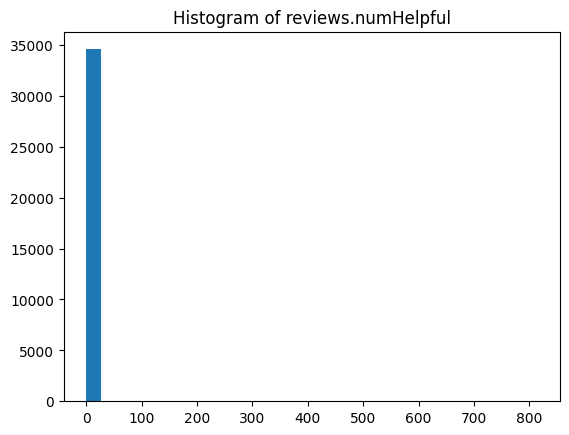

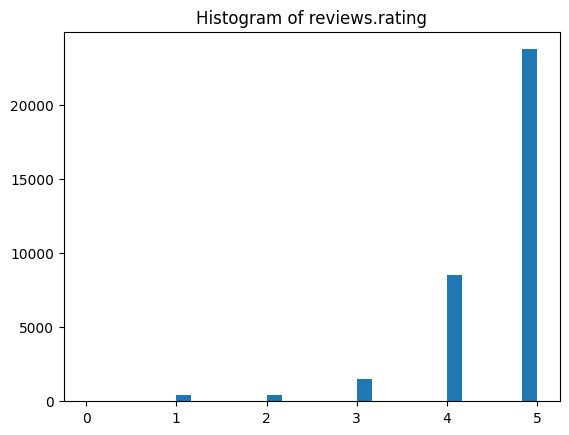

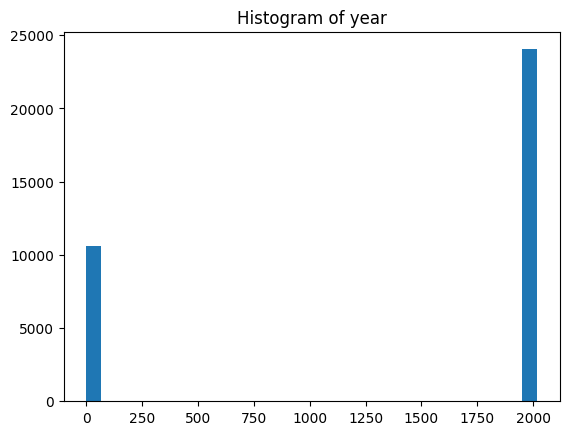

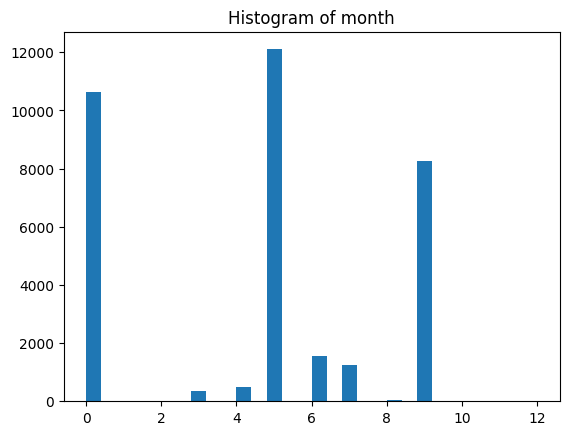

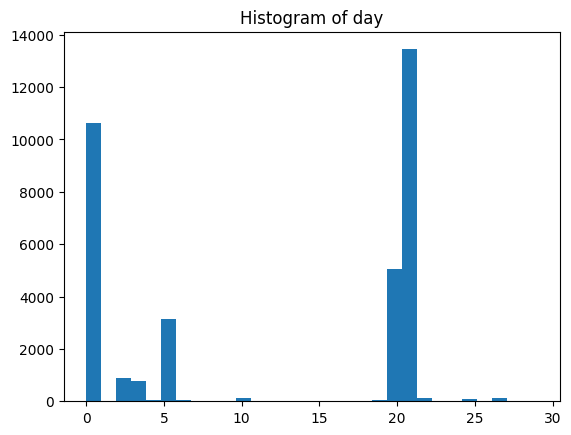

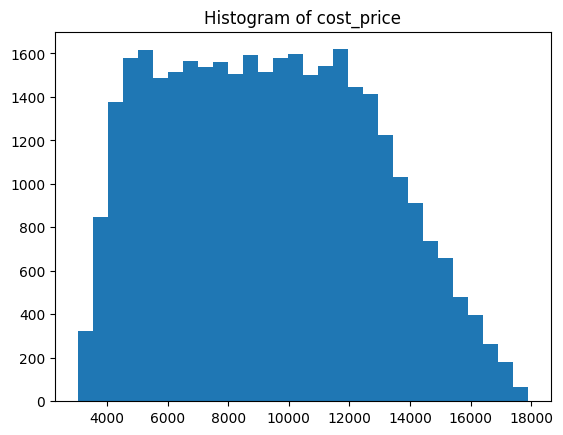

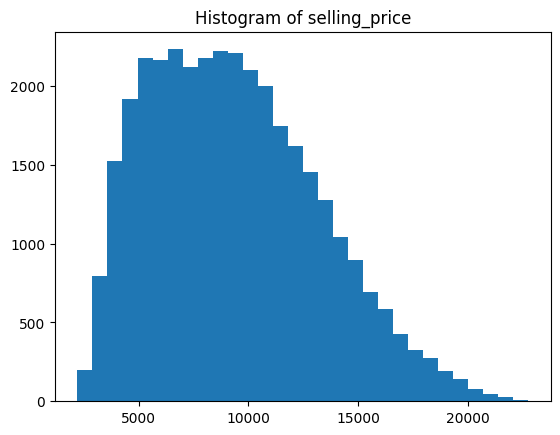

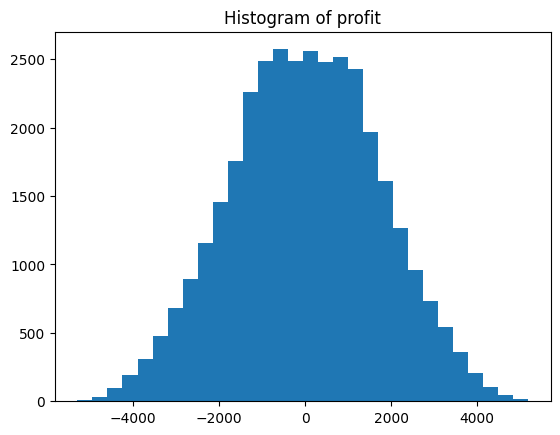

In [497]:
import matplotlib.pyplot as plt

for col in num_cols:
    plt.figure()
    plt.hist(df[col], bins=30)
    plt.title(f'Histogram of {col}')
    plt.show()

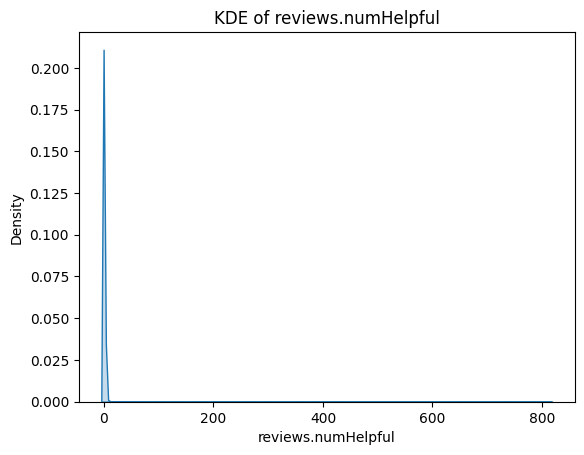

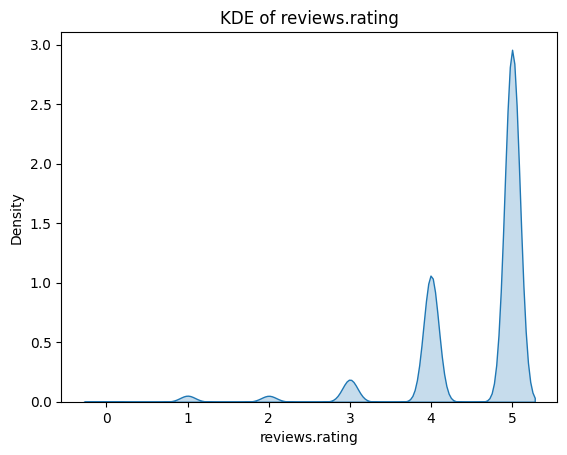

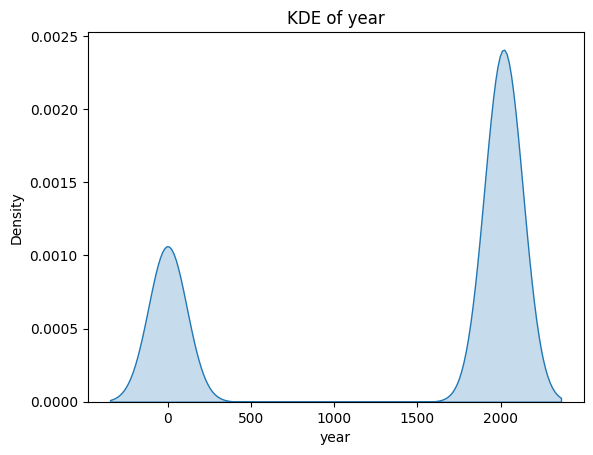

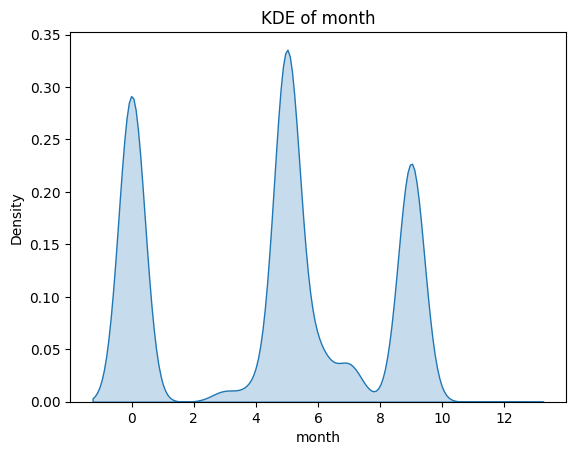

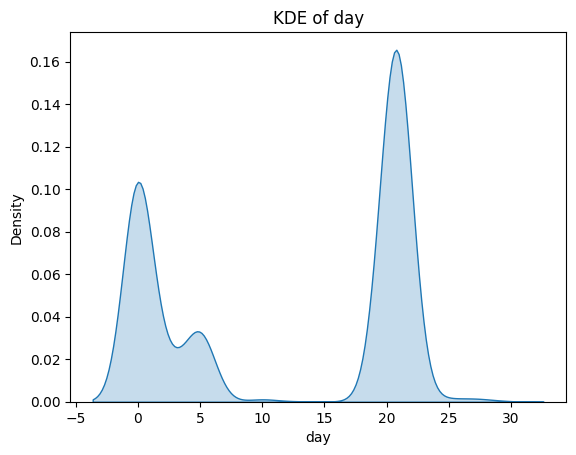

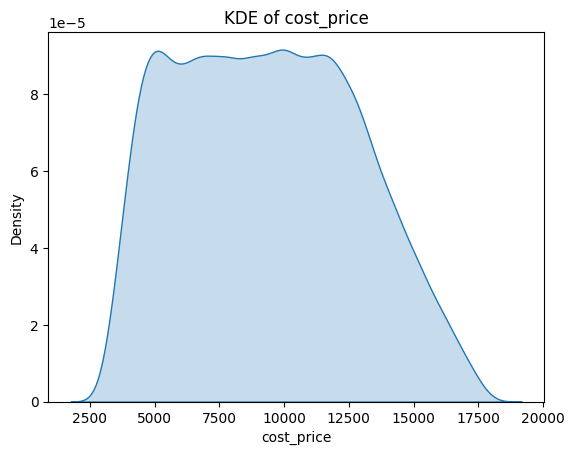

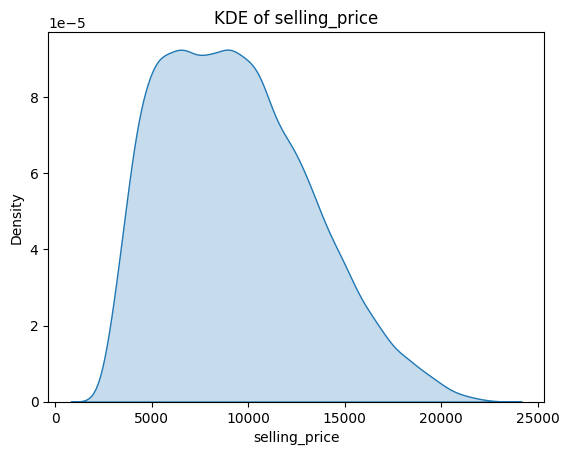

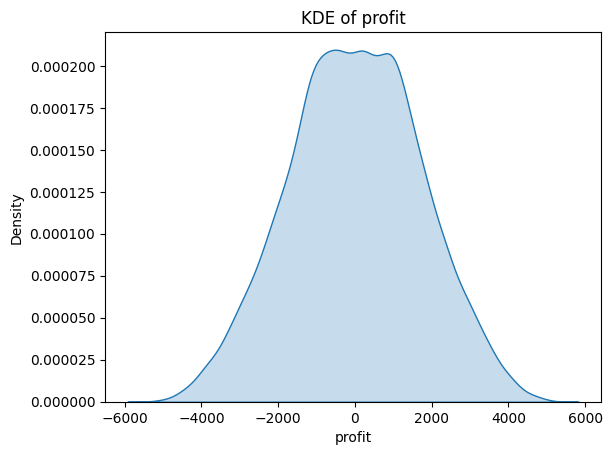

In [498]:
import seaborn as sns

for col in num_cols:
    plt.figure()
    sns.kdeplot(df[col], fill=True)
    plt.title(f'KDE of {col}')
    plt.show()

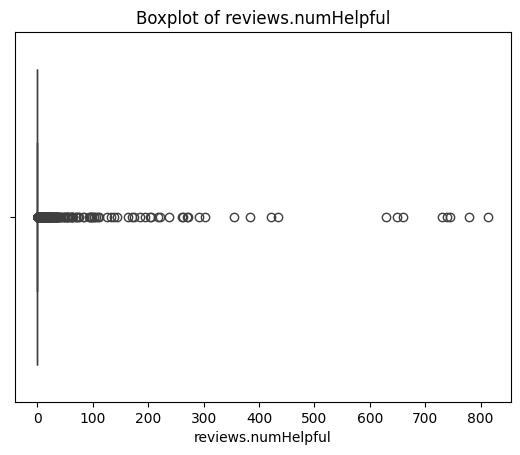

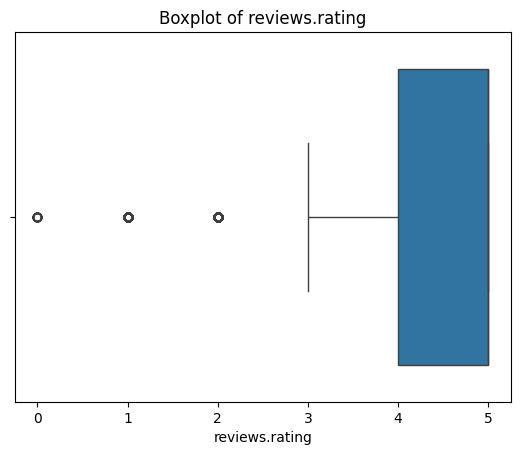

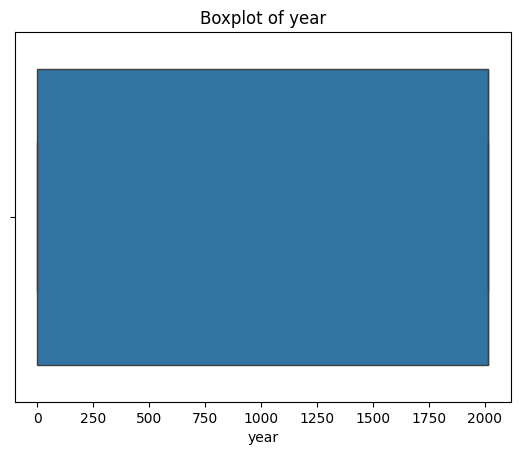

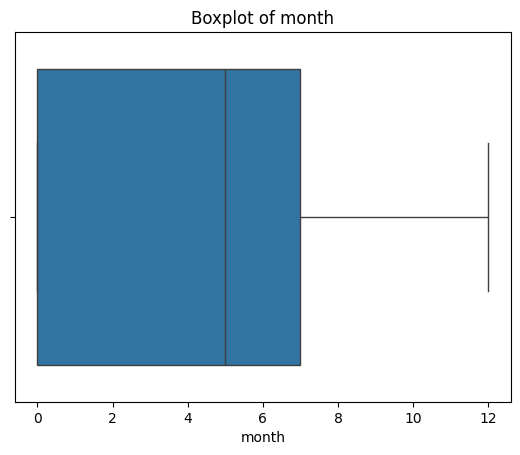

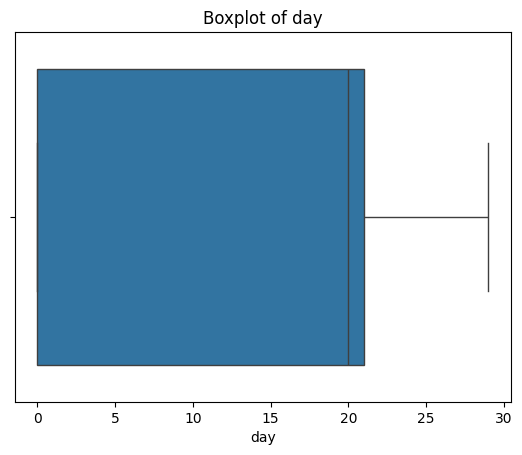

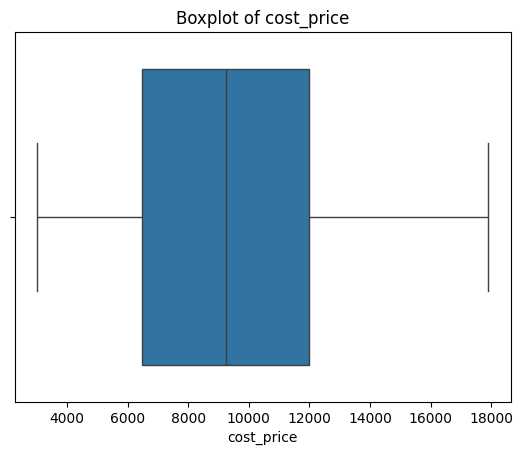

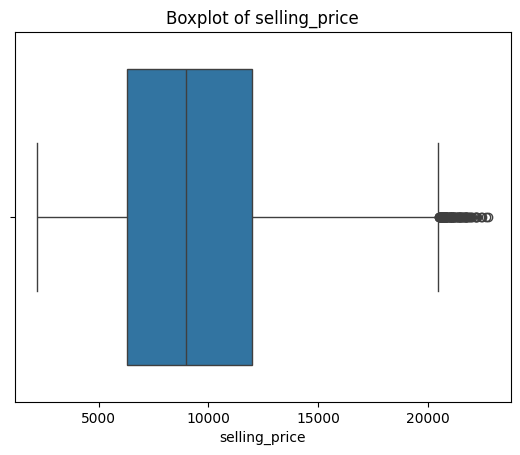

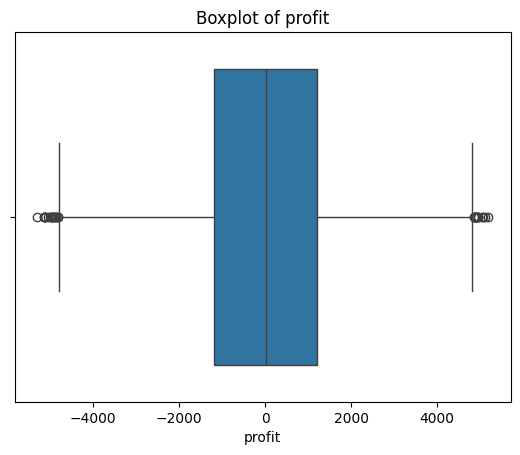

In [499]:
for col in num_cols:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

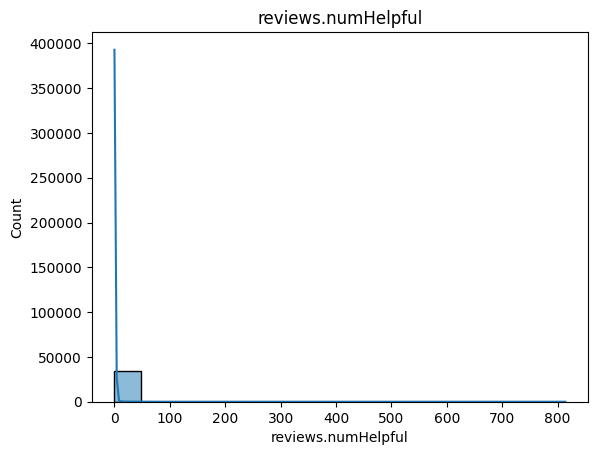

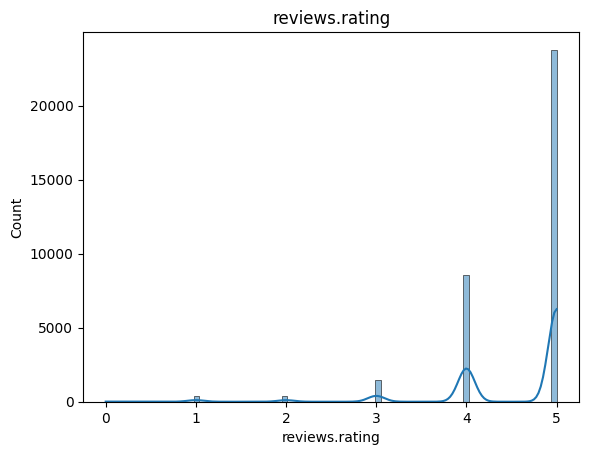

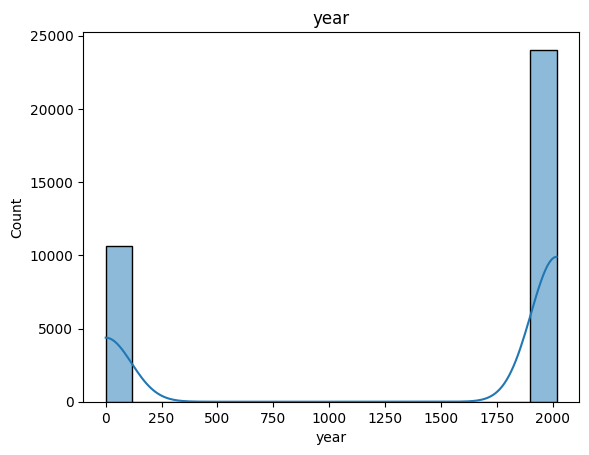

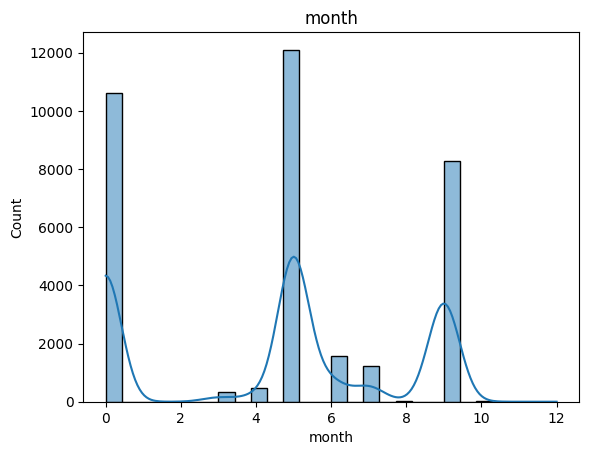

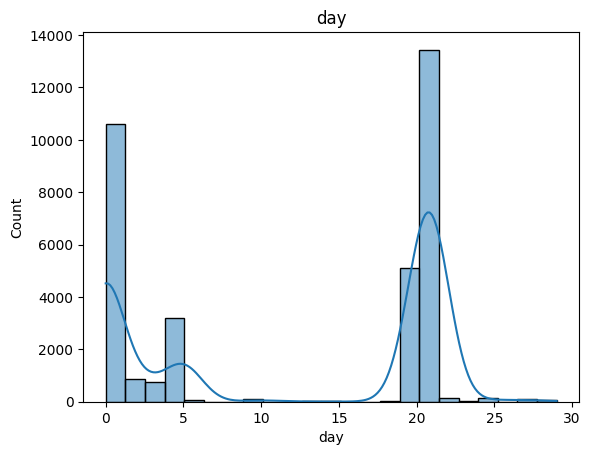

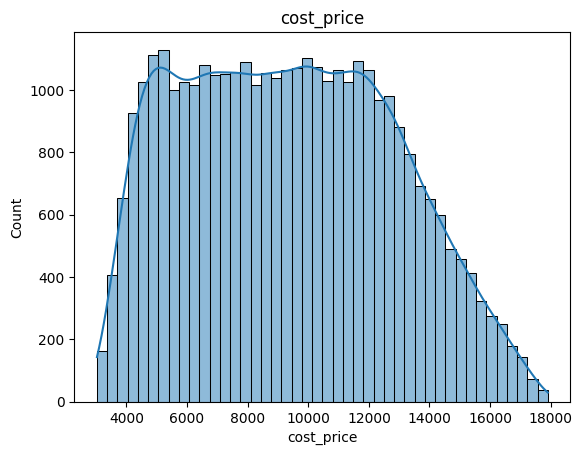

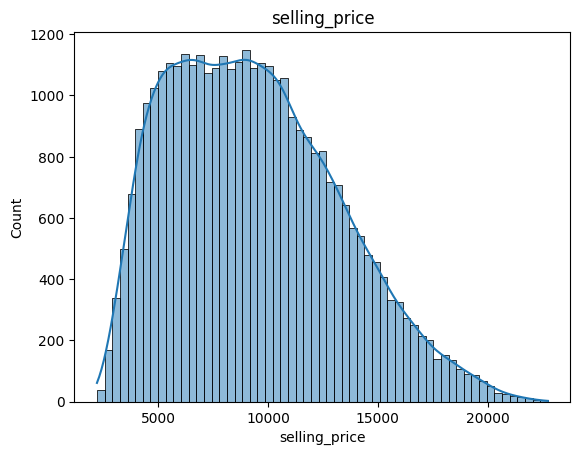

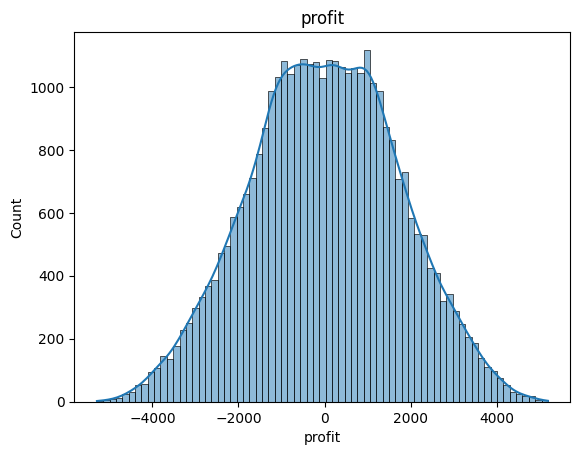

In [500]:
for col in num_cols:
    sns.histplot(df[col], kde=True)
    plt.title(col)
    plt.show()

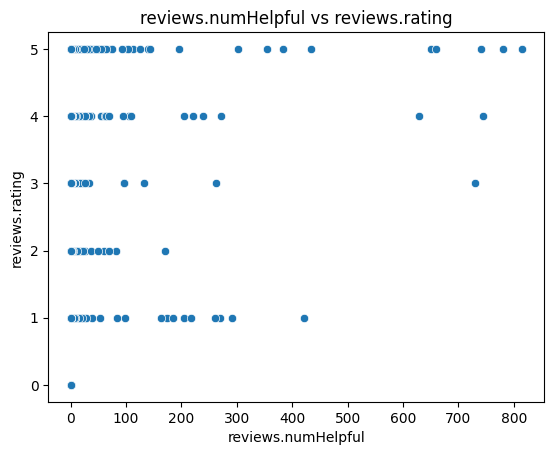

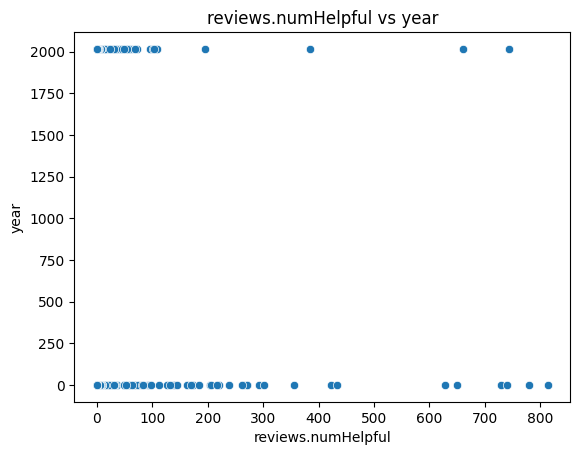

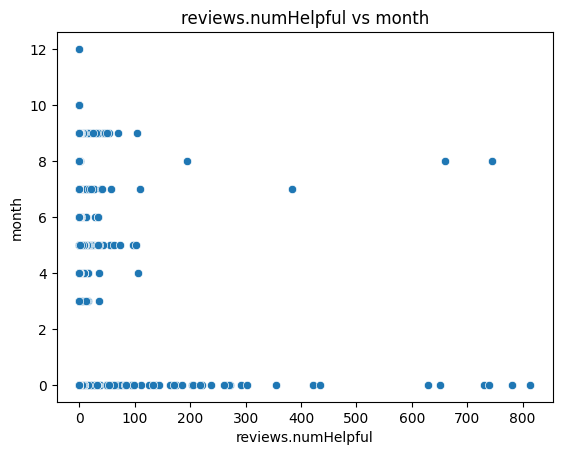

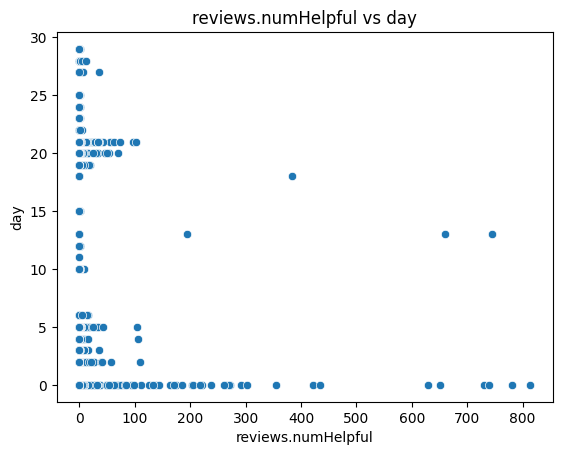

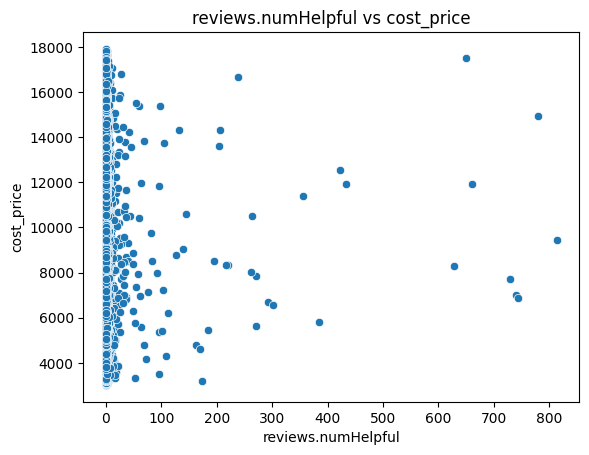

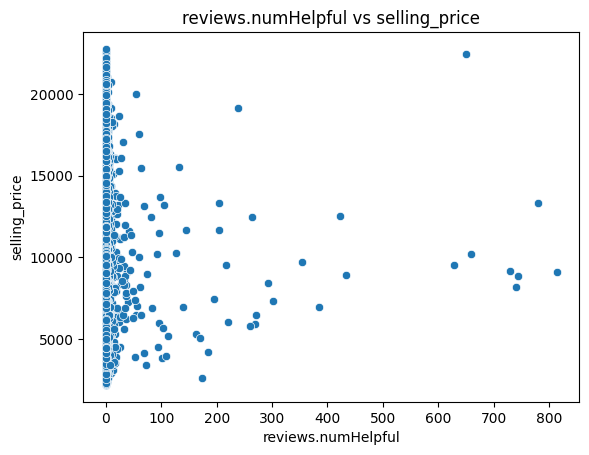

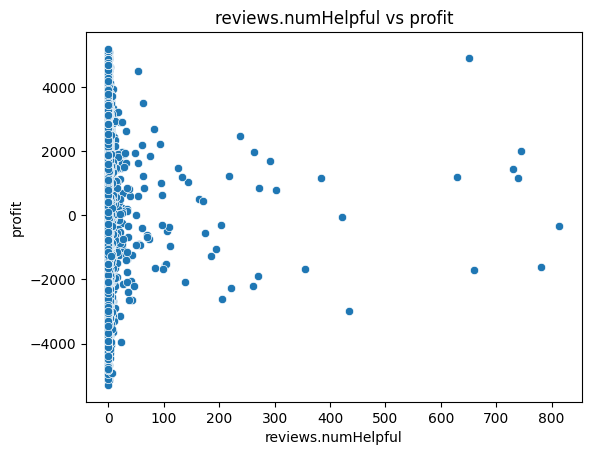

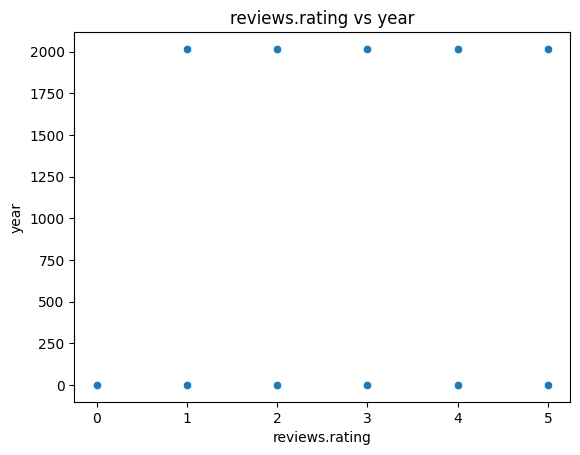

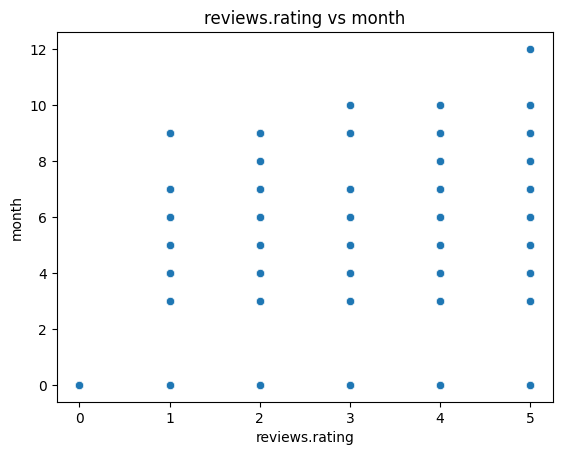

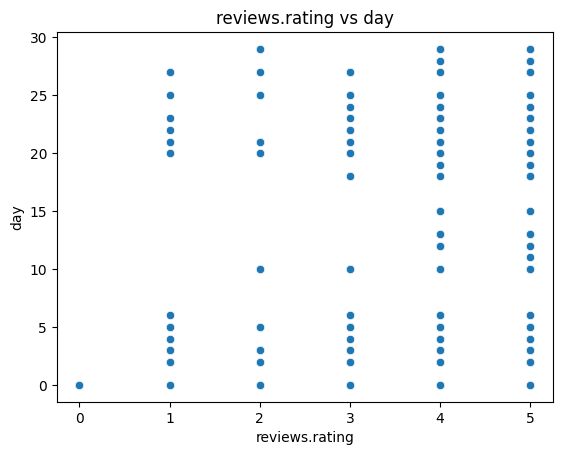

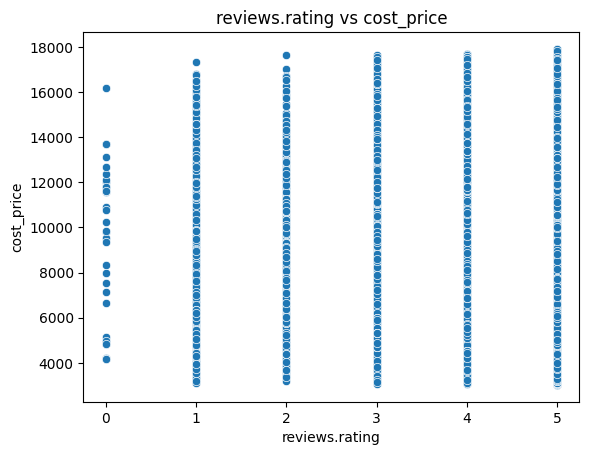

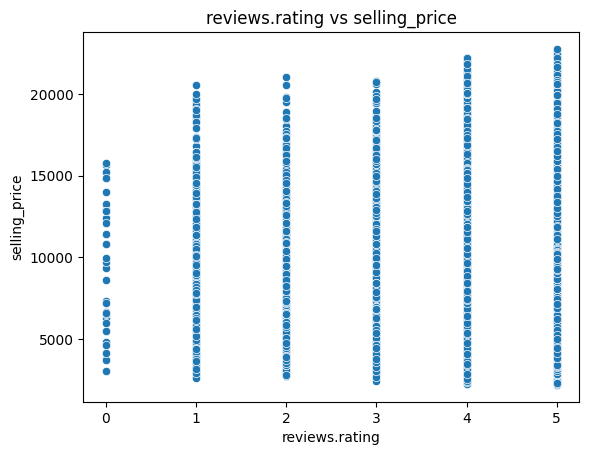

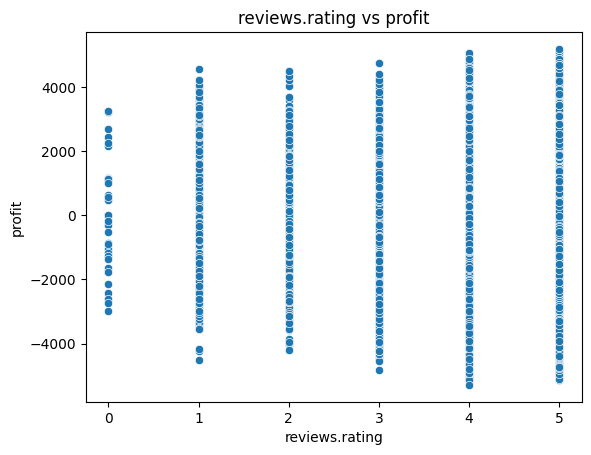

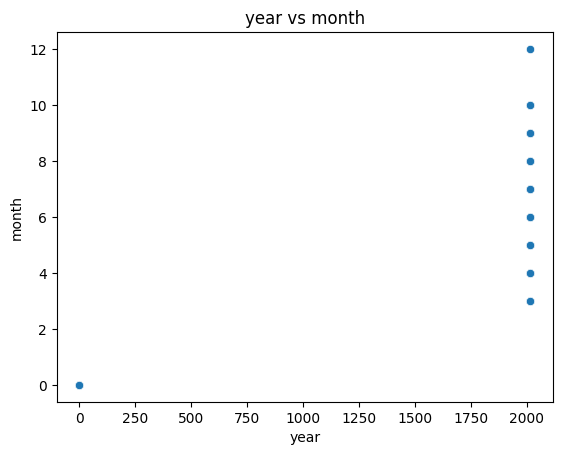

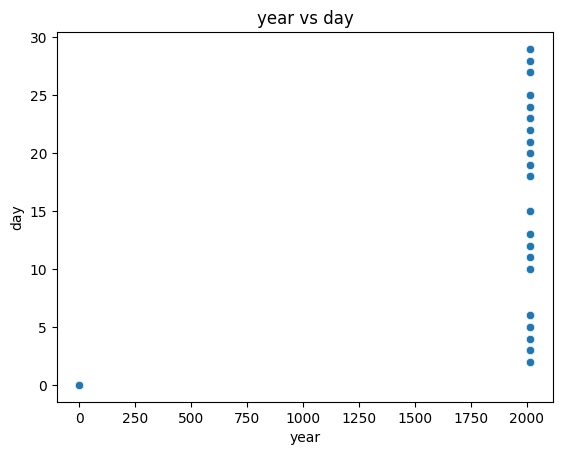

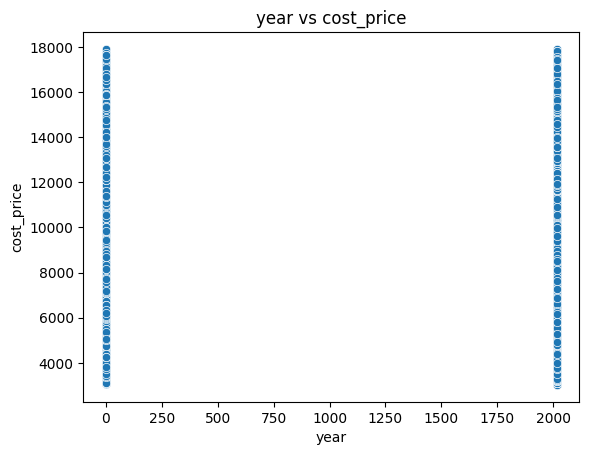

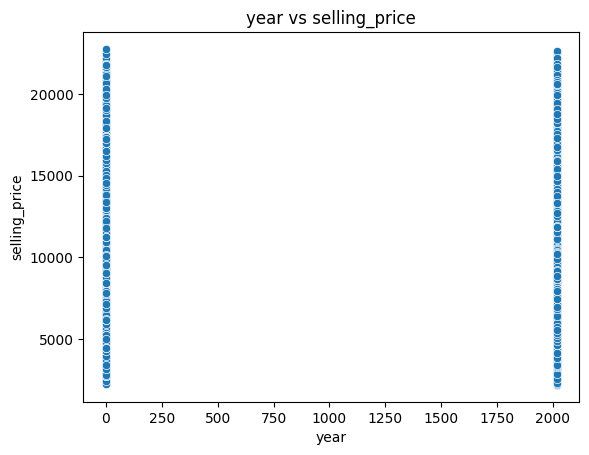

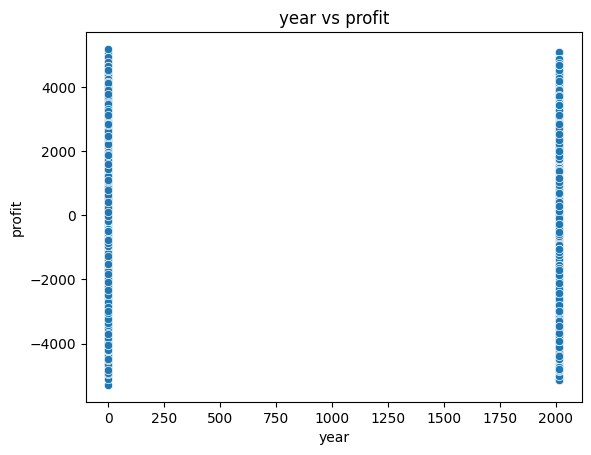

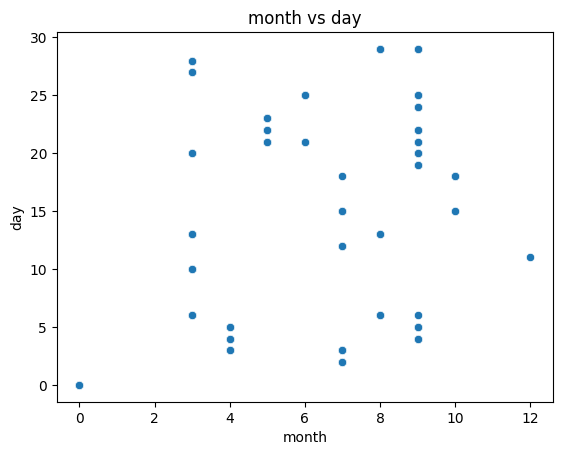

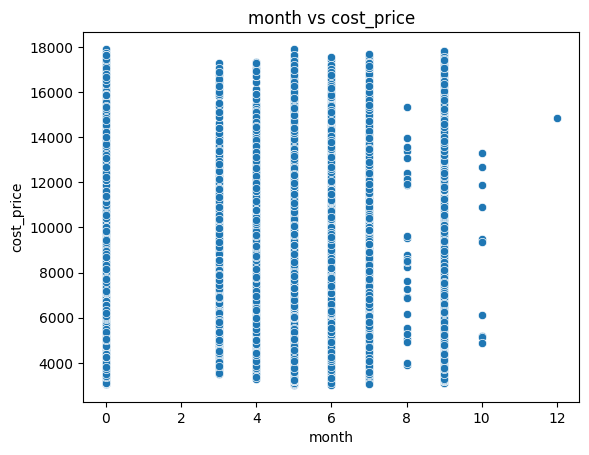

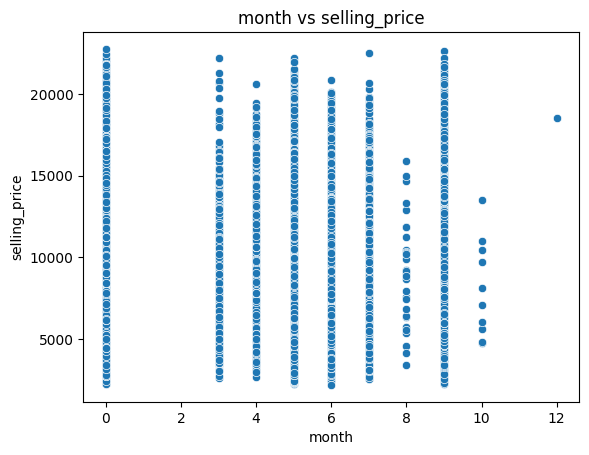

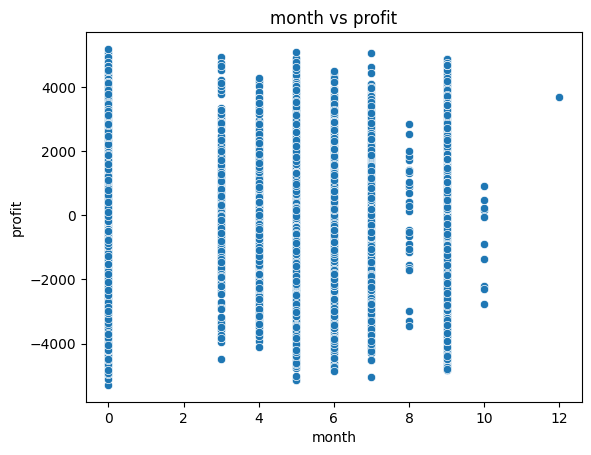

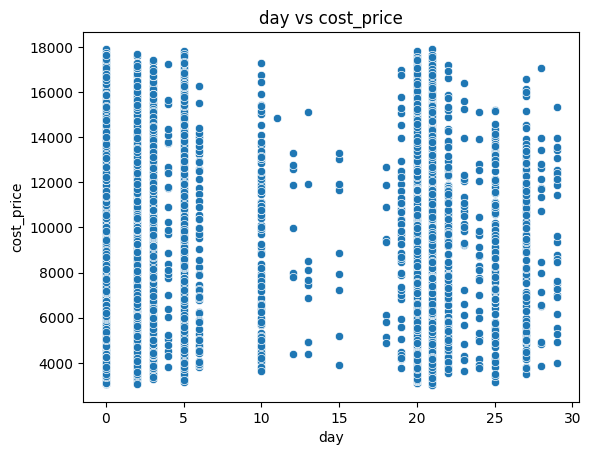

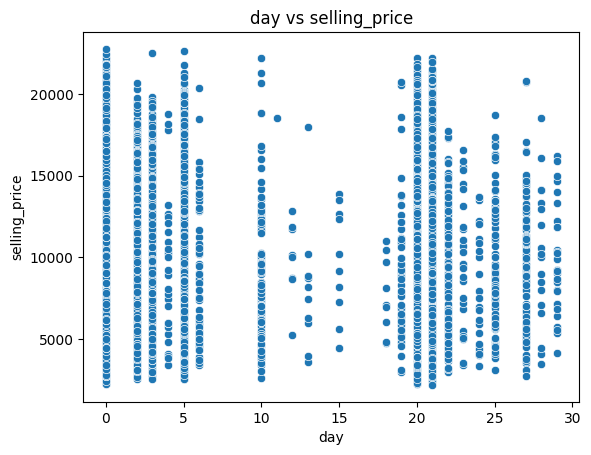

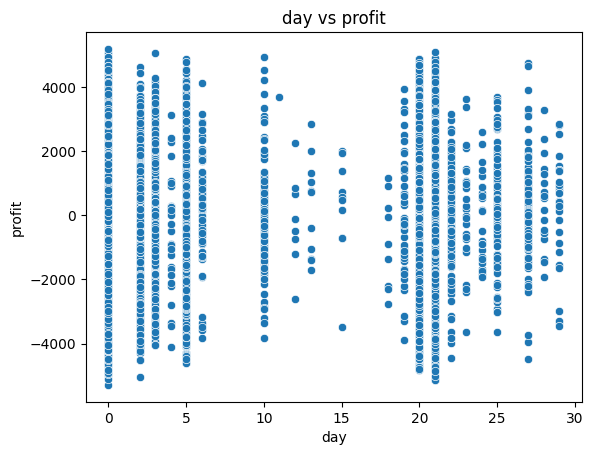

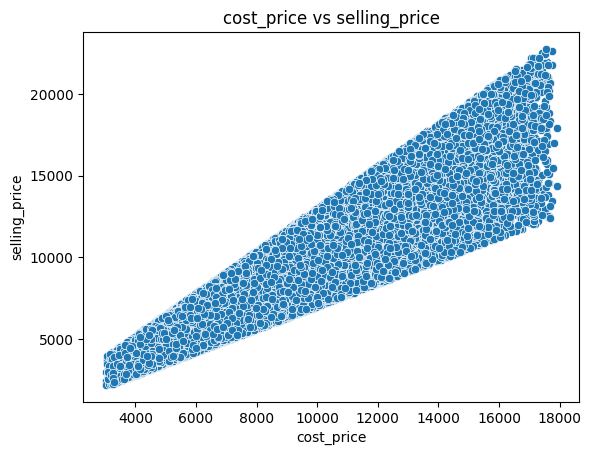

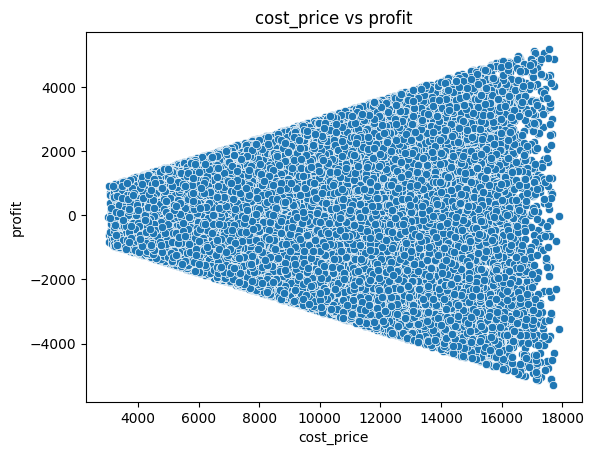

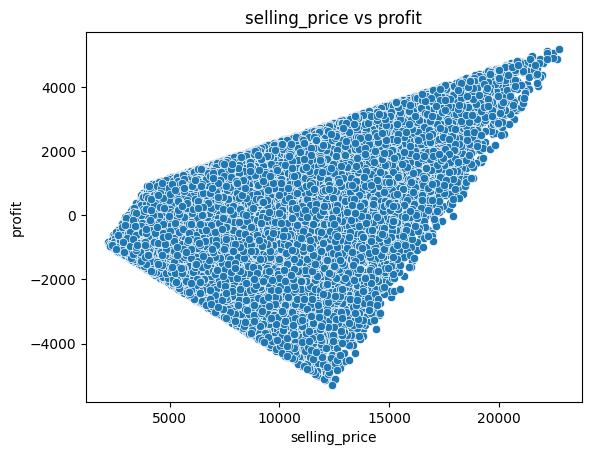

In [501]:
for i in range(len(num_cols)):
    for j in range(i+1, len(num_cols)):
        sns.scatterplot(x=df[num_cols[i]], y=df[num_cols[j]])
        plt.title(f"{num_cols[i]} vs {num_cols[j]}")
        plt.show()

#Regression Plot (trend line)

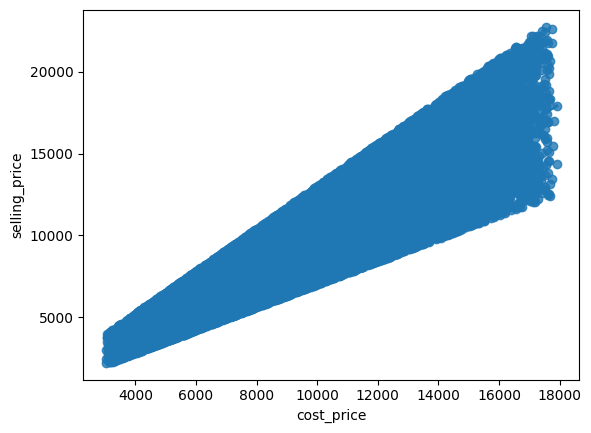

In [502]:
sns.regplot(x='cost_price', y='selling_price', data=df)
plt.show()

#Line Plot

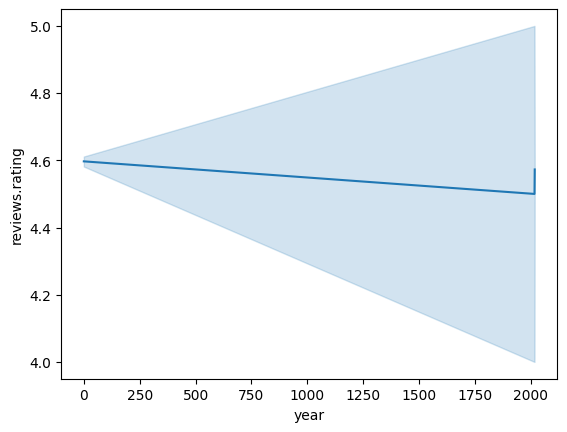

In [503]:
sns.lineplot(x='year', y='reviews.rating', data=df)
plt.show()

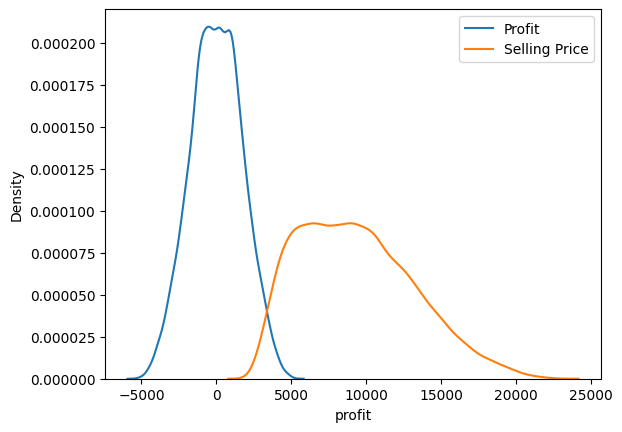

In [504]:
sns.kdeplot(df['profit'], label='Profit')
sns.kdeplot(df['selling_price'], label='Selling Price')
plt.legend()
plt.show()

#Bivariate Analysis

#1. Brand VS rating

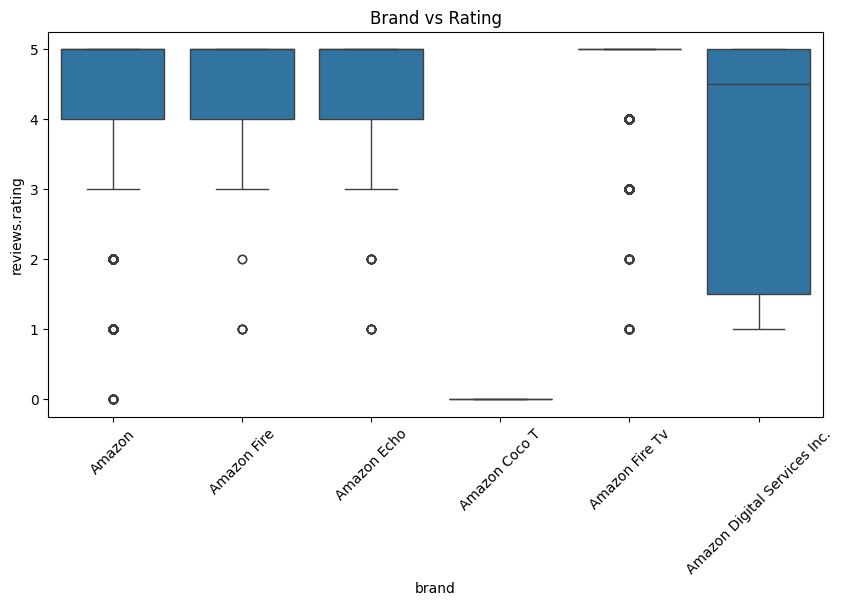

In [450]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
sns.boxplot(x=df['brand'], y=df['reviews.rating'])
plt.xticks(rotation=45)
plt.title("Brand vs Rating")
plt.show()

#2.Recommendation VS Helpfulness

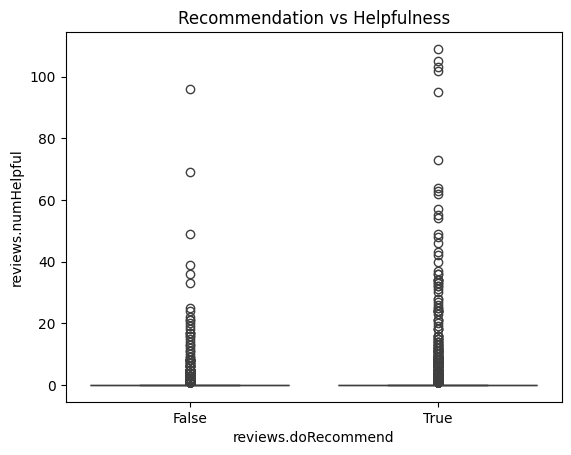

In [451]:
sns.boxplot(x=df['reviews.doRecommend'], y=df['reviews.numHelpful'])
plt.title("Recommendation vs Helpfulness")
plt.show()

#3.Day vs Rating

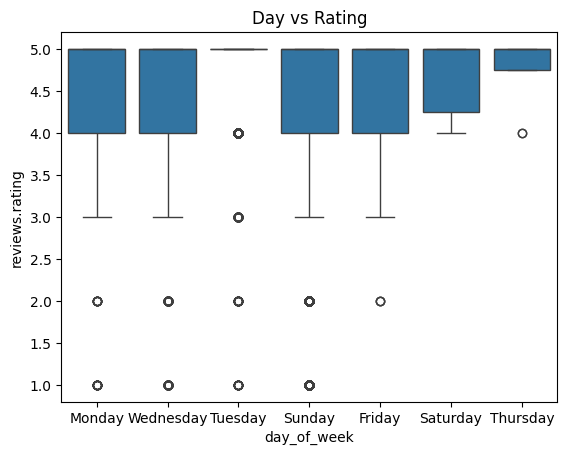

In [452]:
sns.boxplot(x=df['day_of_week'], y=df['reviews.rating'])
plt.title("Day vs Rating")
plt.show()

In [453]:
df.groupby('brand')['reviews.rating'].mean().sort_values(ascending=False)

,reviews.rating
brand,
Amazon Fire Tv,4.707278
Amazon,4.559632
Amazon Fire,4.558594
Amazon Echo,4.531447
Amazon Digital Services Inc.,3.500000
Amazon Coco T,0.000000


In [454]:
df.groupby('day_of_week')['reviews.numHelpful'].mean()

,reviews.numHelpful
day_of_week,
Friday,0.226027
Monday,0.392566
Saturday,0.300000
Sunday,0.444727
Thursday,0.000000
Tuesday,0.476278
Wednesday,0.146278


In [455]:
pd.crosstab(df['brand'], df['reviews.doRecommend'])

reviews.doRecommend,False,True
brand,,
Amazon,1177,26949
Amazon Echo,44,589
Amazon Fire,14,241
Amazon Fire Tv,149,4903


#4.Brand VS Review.doRecommendation

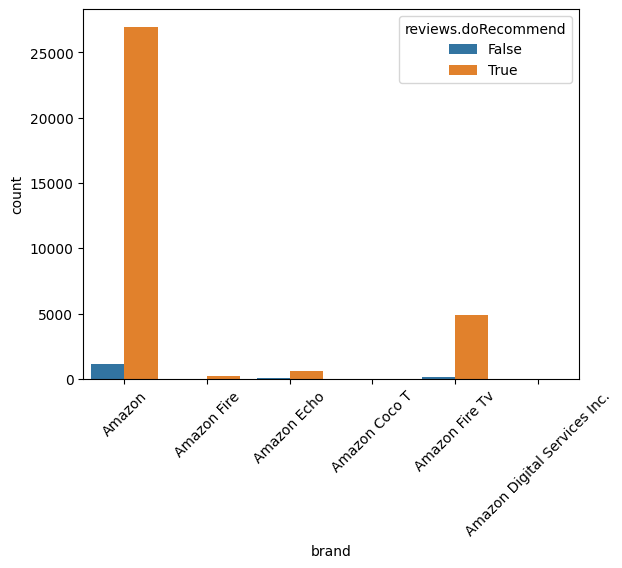

In [456]:
sns.countplot(x='brand', hue='reviews.doRecommend', data=df)
plt.xticks(rotation=45)
plt.show()

#Top Brands

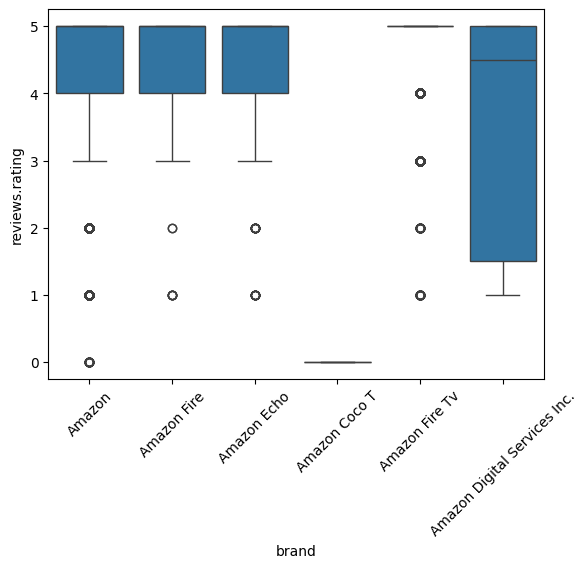

In [457]:
top_brands = df['brand'].value_counts().head(10).index

df_top = df[df['brand'].isin(top_brands)]

sns.boxplot(x=df_top['brand'], y=df_top['reviews.rating'])
plt.xticks(rotation=45)
plt.show()

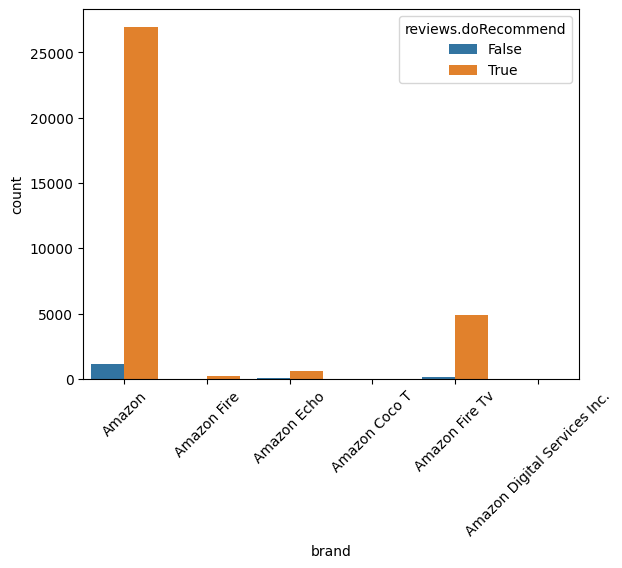

In [505]:
sns.countplot(x='brand', hue='reviews.doRecommend', data=df_top)
plt.xticks(rotation=45)
plt.show()

#6. Day_of week vs review

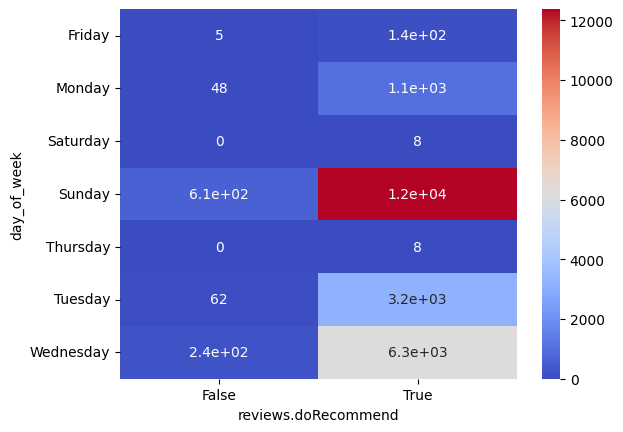

In [458]:
ct = pd.crosstab(df['day_of_week'], df['reviews.doRecommend'])

sns.heatmap(ct, annot=True, cmap='coolwarm')
plt.show()

In [459]:
pd.crosstab(df['brand'], df['reviews.doRecommend'])

reviews.doRecommend,False,True
brand,,
Amazon,1177,26949
Amazon Echo,44,589
Amazon Fire,14,241
Amazon Fire Tv,149,4903


In [460]:
pd.crosstab(df['brand'], df['reviews.doRecommend'], normalize='index')

reviews.doRecommend,False,True
brand,,
Amazon,0.041847,0.958153
Amazon Echo,0.069510,0.930490
Amazon Fire,0.054902,0.945098
Amazon Fire Tv,0.029493,0.970507


#7.Brand vs Recommendation

```
```



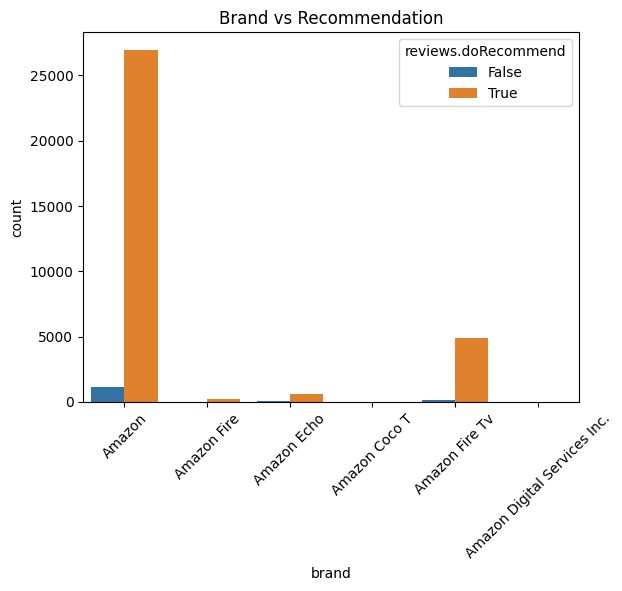

In [461]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='brand', hue='reviews.doRecommend', data=df)
plt.xticks(rotation=45)
plt.title("Brand vs Recommendation")
plt.show()

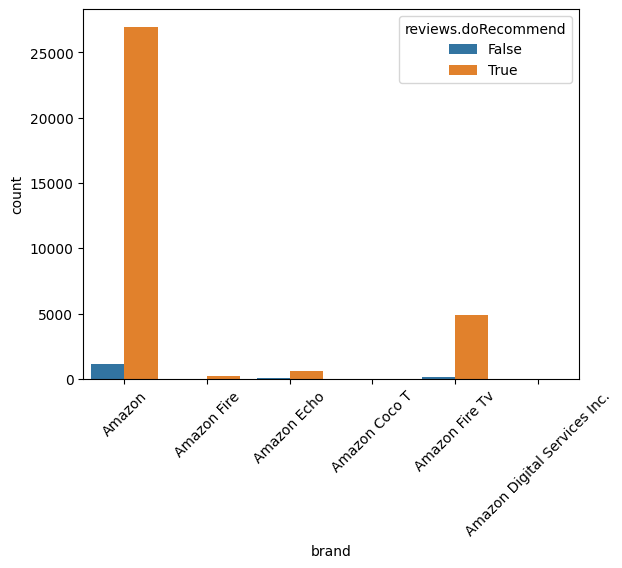

In [462]:
top_brands = df['brand'].value_counts().head(10).index
df_top = df[df['brand'].isin(top_brands)]

sns.countplot(x='brand', hue='reviews.doRecommend', data=df_top)
plt.xticks(rotation=45)
plt.show()

In [463]:
pd.crosstab(df['brand'], df['day_of_week'])

day_of_week,Friday,Monday,Saturday,Sunday,Thursday,Tuesday,Wednesday
brand,,,,,,,
Amazon,138,1094,10,12987,0,3245,1509
Amazon Fire Tv,8,9,0,3,8,22,5006


In [464]:
ct = pd.crosstab(df['brand'], df['reviews.doRecommend'], normalize='index') * 100
print(ct)

reviews.doRecommend     False      True 
brand                                   
Amazon               4.184740  95.815260
Amazon Echo          6.951027  93.048973
Amazon Fire          5.490196  94.509804
Amazon Fire Tv       2.949327  97.050673


In [465]:
df.groupby('brand')['reviews.rating'].mean().sort_values(ascending=False)

,reviews.rating
brand,
Amazon Fire Tv,4.707278
Amazon,4.559632
Amazon Fire,4.558594
Amazon Echo,4.531447
Amazon Digital Services Inc.,3.500000
Amazon Coco T,0.000000


#8.day_of_week vs reviews.rating

In [466]:
df.groupby('day_of_week')['reviews.rating'].mean()

,reviews.rating
day_of_week,
Friday,4.513699
Monday,4.553037
Saturday,4.700000
Sunday,4.479061
Thursday,4.750000
Tuesday,4.768595
Wednesday,4.665848


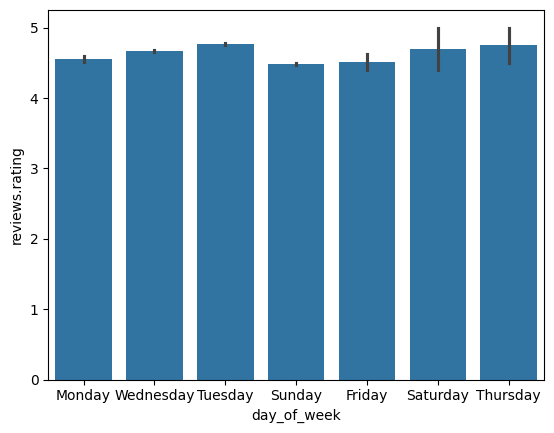

In [467]:
sns.barplot(x='day_of_week', y='reviews.rating', data=df)
plt.show()

In [469]:
df.groupby('brand')['reviews.rating'].agg(['mean', 'min', 'max', 'count'])

,mean,min,max,count
brand,,,,
Amazon,4.559632,0.0,5.0,28701
Amazon Coco T,0.000000,0.0,0.0,1
Amazon Digital Services Inc.,3.500000,1.0,5.0,10
Amazon Echo,4.531447,1.0,5.0,636
Amazon Fire,4.558594,1.0,5.0,256
Amazon Fire Tv,4.707278,1.0,5.0,5056


In [470]:
pd.pivot_table(df, values='reviews.rating', index='brand', columns='reviews.doRecommend', aggfunc='mean')

reviews.doRecommend,False,True
brand,,
Amazon,2.465590,4.662028
Amazon Echo,2.477273,4.682513
Amazon Fire,2.214286,4.701245
Amazon Fire Tv,2.577181,4.771976


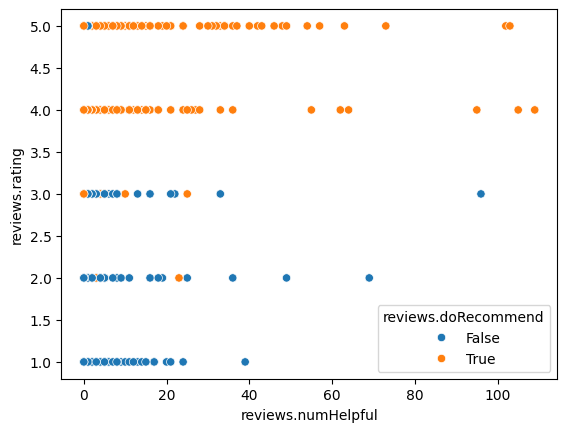

In [471]:
sns.scatterplot(x='reviews.numHelpful', y='reviews.rating', hue='reviews.doRecommend', data=df)
plt.show()

In [472]:
cat_cols

Index(['id', 'name', 'asins', 'brand', 'categories', 'keys', 'manufacturer',
       'reviews.date', 'reviews.dateSeen', 'reviews.doRecommend',
       'reviews.sourceURLs', 'reviews.text', 'reviews.title',
       'reviews.username', 'day_of_week'],
      dtype='object')

In [473]:
print(df.columns)

Index(['id', 'name', 'asins', 'brand', 'categories', 'keys', 'manufacturer',
       'reviews.date', 'reviews.dateAdded', 'reviews.dateSeen',
       'reviews.doRecommend', 'reviews.numHelpful', 'reviews.rating',
       'reviews.sourceURLs', 'reviews.text', 'reviews.title',
       'reviews.username', 'year', 'month', 'day', 'day_of_week',
       'helpfulness_ratio', 'categories_list', 'main_category', 'sub_category',
       'is_tablet', 'is_kindle', 'is_electronics', 'is_smart_device',
       'num_categories', 'price', 'cost_price', 'selling_price'],
      dtype='object')


In [474]:
num_cols

Index(['reviews.numHelpful', 'reviews.rating', 'year', 'month', 'day'], dtype='object')

In [489]:
num_cols = [
 'reviews.numHelpful', 'reviews.rating', 'year', 'month', 'day',
 'cost_price', 'selling_price', 'profit'
]

In [490]:
df[num_cols].head()

,reviews.numHelpful,reviews.rating,year,month,day,cost_price,selling_price,profit
0,0.0,5.0,2017.0,7.0,3.0,7533.687181,6926.055863,-607.631318
1,0.0,5.0,2017.0,7.0,3.0,3956.381807,2809.444957,-1146.936851
2,0.0,5.0,2017.0,7.0,3.0,7336.602134,6258.821804,-1077.780330
3,0.0,4.0,2017.0,7.0,3.0,15136.742604,12302.745765,-2833.996839
4,0.0,5.0,2017.0,7.0,3.0,7625.627498,5958.161923,-1667.465575


In [478]:
print(df.columns)

Index(['id', 'name', 'asins', 'brand', 'categories', 'keys', 'manufacturer',
       'reviews.date', 'reviews.dateAdded', 'reviews.dateSeen',
       'reviews.doRecommend', 'reviews.numHelpful', 'reviews.rating',
       'reviews.sourceURLs', 'reviews.text', 'reviews.title',
       'reviews.username', 'year', 'month', 'day', 'day_of_week',
       'helpfulness_ratio', 'categories_list', 'main_category', 'sub_category',
       'is_tablet', 'is_kindle', 'is_electronics', 'is_smart_device',
       'num_categories', 'price', 'cost_price', 'selling_price'],
      dtype='object')


##Outliers

In [506]:
outliers = {}

for col in num_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1

    upper_limit = q3 + 1.5 * iqr
    lower_limit = q1 - 1.5 * iqr

    # Detect outliers
    outlier_data = df[(df[col] > upper_limit) | (df[col] < lower_limit)]

    # Store in dictionary
    outliers[col] = outlier_data

    print(f"{col}: {len(outlier_data)} outliers")

reviews.numHelpful: 3311 outliers
reviews.rating: 845 outliers
year: 0 outliers
month: 0 outliers
day: 0 outliers
cost_price: 0 outliers
selling_price: 95 outliers
profit: 32 outliers


In [507]:
import numpy as np
df['reviews.numHelpful'] = np.log1p(df['reviews.numHelpful'])

In [508]:
for col in ['selling_price', 'profit']:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    df[col] = df[col].clip(lower, upper)

In [509]:
drop_cols = [
 'id', 'name', 'asins', 'keys',
 'reviews.text', 'reviews.title',
 'reviews.username', 'reviews.sourceURLs',
 'categories', 'categories_list'
]

df.drop(columns=drop_cols, inplace=True)

In [514]:
num_cols = [
 'reviews.numHelpful',
 'reviews.rating',
 'year',
 'month',
 'profit'
]

In [515]:
cat_cols = [
 'brand',
 'reviews.doRecommend',
 'day_of_week',
 'main_category',
 'sub_category',
 'profit_status'
]

In [536]:
df.isnull().mean()*100

,0
brand,0.000000
reviews.date,0.112522
reviews.dateAdded,30.643393
reviews.dateSeen,0.000000
reviews.doRecommend,1.713791
reviews.numHelpful,0.000000
reviews.rating,0.000000
year,0.000000
month,0.000000
day_of_week,30.643393


In [537]:
df = df.dropna(subset=['reviews.doRecommend'])

In [538]:
df['reviews.doRecommend'] = df['reviews.doRecommend'].astype(int)

In [539]:
df.drop(columns=['reviews.dateAdded'], inplace=True)

In [540]:
df['day_of_week'] = df['day_of_week'].fillna(df['day_of_week'].mode()[0])

In [541]:
df.drop(columns=['reviews.date', 'reviews.dateSeen'], inplace=True)

In [542]:
df.isnull().sum()

,0
brand,0
reviews.doRecommend,0
reviews.numHelpful,0
reviews.rating,0
year,0
month,0
day_of_week,0
helpfulness_ratio,0
main_category,0
sub_category,0


In [543]:
num_cols = [col for col in df.columns if col.startswith('num__')]
cat_cols = [col for col in df.columns if col.startswith('cat__')]

In [544]:
cat_cols = [col for col in df.columns if col.startswith('cat__')]

df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

In [545]:
y = df['reviews.doRecommend']

In [546]:
y = df['reviews.doRecommend'].astype(int)

In [547]:
X = df[[
 'reviews.numHelpful',
 'year',
 'month',
 'profit',
 'brand',
 'day_of_week',
 'main_category',
 'sub_category'
]]

In [548]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [549]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

num_cols = ['reviews.numHelpful', 'year', 'month', 'profit']
cat_cols = ['brand', 'day_of_week', 'main_category', 'sub_category']

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
])

In [561]:
from xgboost import XGBClassifier

ratio = len(y_train[y_train == 0]) / len(y_train[y_train == 1])

model = XGBClassifier(
    scale_pos_weight=ratio,
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1
)

In [563]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(class_weight='balanced')

In [564]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.25      0.01      0.02       277
           1       0.96      1.00      0.98      6537

    accuracy                           0.96      6814
   macro avg       0.60      0.50      0.50      6814
weighted avg       0.93      0.96      0.94      6814



In [565]:
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', model)
])

In [566]:
pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['reviews.numHelpful', 'year',
                                                   'month', 'profit']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['brand', 'day_of_week',
                                                   'main_category',
                                                   'sub_category'])])),
                ('model', LogisticRegression(class_weight='balanced'))])

In [554]:
y_pred = pipeline.predict(X_test)

In [555]:
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9584678602876431


In [556]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.25      0.01      0.02       277
           1       0.96      1.00      0.98      6537

    accuracy                           0.96      6814
   macro avg       0.60      0.50      0.50      6814
weighted avg       0.93      0.96      0.94      6814



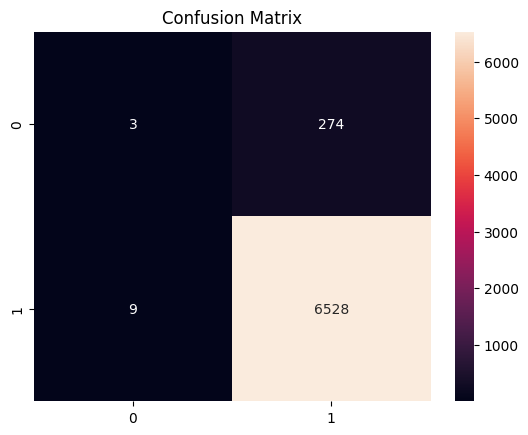

In [557]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

In [558]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [4, 6],
}

grid = GridSearchCV(pipeline, param_grid, cv=3)
grid.fit(X_train, y_train)

print(grid.best_params_)

{'model__max_depth': 4, 'model__n_estimators': 100}


In [559]:
model = pipeline.named_steps['model']
importances = model.feature_importances_

In [560]:
new_data = X_test.iloc[:1]
pipeline.predict(new_data)

array([1])